# Setting

In [1]:
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Paths
BASE_DIR = Path('../')
NETWORK_DIR = BASE_DIR / 'result' / 'networks'
OUTPUT_DIR = BASE_DIR / 'result'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'
DATA_FILE = BASE_DIR / 'db' / 'total_only_org.csv'

# Create directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Set style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

In [4]:
M_GROUPS = [
    ('남성', '청년층(19-39세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(+)'),
    ('남성', '장년층(60-74세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(-)'),
    ('남성', '청년층(19-39세)', 'MetS(-)'),
    ('남성', '장년층(60-74세)', 'MetS(-)'),
]
F_GROUPS = [
    ('여성', '중년층(40-59세)', 'MetS(+)'),
    ('여성', '장년층(60-74세)', 'MetS(+)'),
    ('여성', '청년층(19-39세)', 'MetS(-)'),
    ('여성', '중년층(40-59세)', 'MetS(-)'),
    ('여성', '장년층(60-74세)', 'MetS(-)'),
]

M_GROUP_LABELS = [
    'Male_Young_MetS(+)',
    'Male_Middle_MetS(+)',
    'Male_Older_MetS(+)',
    'Male_Young_MetS(-)',
    'Male_Middle_MetS(-)',
    'Male_Older_MetS(-)',
]
F_GROUP_LABELS = [
    'Female_Middle_MetS(+)',
    'Female_Older_MetS(+)',
    'Female_Young_MetS(-)',
    'Female_Middle_MetS(-)',
    'Female_Older_MetS(-)',
]

GROUPS = M_GROUPS + F_GROUPS
GROUP_LABELS = M_GROUP_LABELS + F_GROUP_LABELS

GROUP_MAPPING = {
    'Male_Young': ('남성', '청년층(19-39세)'),
    'Male_Middle': ('남성', '중년층(40-59세)'),
    'Male_Older': ('남성', '장년층(60-74세)'),
    'Female_Young': ('여성', '청년층(19-39세)'),
    'Female_Middle': ('여성', '중년층(40-59세)'),
    'Female_Older': ('여성', '장년층(60-74세)'),
}

SEX_DISPLAY = {'M': '남성', 'F': '여성'}
SEX_REVERSE = {'남성': 'M', '여성': 'F'}

FOOD_ABBREV = {
    'Grain Products': 'GRAIN',
    'Protein Foods': 'PROTEIN',
    'Vegetables': 'VEG',
    'Dairy Products': 'DAIRY',
    'Fruits': 'FRUIT',
    'Fried Foods': 'FRIED',
    'High Fat Meat': 'HIGH_FAT_MEAT',
    'Processed Foods': 'Processed',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'ADD_SALT',
    'Salty Food Consumption': 'SALTY',
    'Sweet Food Consumption': 'SWEET'
}

def load_raw_data():
    df = pd.read_csv(DATA_FILE)
    
    def categorize_age(age):
        if age < 40:
            return '청년층(19-39세)'
        elif age < 60:
            return '중년층(40-59세)'
        else:
            return '장년층(60-74세)'
    
    df['Age_Group'] = df['Age'].apply(categorize_age)
    df['MetS_Status'] = df['MetS'].apply(lambda x: 'MetS(+)' if x == 1 else 'MetS(-)')
    return df

def load_network(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}.gexf"
    filepath = NETWORK_DIR / filename
    if filepath.exists():
        return nx.read_gexf(str(filepath))
    return None

def load_statistics():
    stats_file = NETWORK_DIR / 'ggm_network_summary.csv'
    if stats_file.exists():
        return pd.read_csv(stats_file)
    return None

def load_all_community_data():
    summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
    
    all_data = []
    for _, row in summary_df.iterrows():
        group = row['Group']
        
        community_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
        if community_file.exists():
            comm_df = pd.read_csv(community_file)
            comm_df['Group'] = group
            all_data.append(comm_df)
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

def load_partial_corr_matrix(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}_partial_corr.csv"
    filepath = NETWORK_DIR / filename
    
    if filepath.exists():
        return pd.read_csv(filepath, index_col=0)
    return None

# 3.1. Study Population Characteristics

## TABLE 1: Population Characteristics by MetS Status and Subgroups

In [5]:
# Load raw data for population characteristics
df_raw = load_raw_data()

# Overall comparison: MetS(-) vs MetS(+)
mets_neg = df_raw[df_raw['MetS_Status'] == 'MetS(-)']
mets_pos = df_raw[df_raw['MetS_Status'] == 'MetS(+)']

table1_overall = pd.DataFrame({
    'Characteristic': ['N', 'Age (years)', 'BMI (kg/m²)', 'Waist Circumference (cm)', 
                      'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 
                      'Fasting Glucose (mg/dL)', 'Triglycerides (mg/dL)', 'HDL (mg/dL)'],
    'MetS(-)': [
        len(mets_neg),
        f"{mets_neg['Age'].mean():.1f} ± {mets_neg['Age'].std():.1f}",
        f"{mets_neg['BMI(kg/m2)'].mean():.1f} ± {mets_neg['BMI(kg/m2)'].std():.1f}",
        f"{mets_neg['Waist circumference (cm)'].mean():.1f} ± {mets_neg['Waist circumference (cm)'].std():.1f}",
        f"{mets_neg['Systolic blood pressure (mmHg)'].mean():.1f} ± {mets_neg['Systolic blood pressure (mmHg)'].std():.1f}",
        f"{mets_neg['Diastolic Blood Pressure (mmHg)'].mean():.1f} ± {mets_neg['Diastolic Blood Pressure (mmHg)'].std():.1f}",
        f"{mets_neg['Fasting glucose (mg/dL)'].mean():.1f} ± {mets_neg['Fasting glucose (mg/dL)'].std():.1f}",
        f"{mets_neg['Triglycerides (mg/dL)'].mean():.1f} ± {mets_neg['Triglycerides (mg/dL)'].std():.1f}",
        f"{mets_neg['HDL-C (mg/dL)'].mean():.1f} ± {mets_neg['HDL-C (mg/dL)'].std():.1f}",
    ],
    'MetS(+)': [
        len(mets_pos),
        f"{mets_pos['Age'].mean():.1f} ± {mets_pos['Age'].std():.1f}",
        f"{mets_pos['BMI(kg/m2)'].mean():.1f} ± {mets_pos['BMI(kg/m2)'].std():.1f}",
        f"{mets_pos['Waist circumference (cm)'].mean():.1f} ± {mets_pos['Waist circumference (cm)'].std():.1f}",
        f"{mets_pos['Systolic blood pressure (mmHg)'].mean():.1f} ± {mets_pos['Systolic blood pressure (mmHg)'].std():.1f}",
        f"{mets_pos['Diastolic Blood Pressure (mmHg)'].mean():.1f} ± {mets_pos['Diastolic Blood Pressure (mmHg)'].std():.1f}",
        f"{mets_pos['Fasting glucose (mg/dL)'].mean():.1f} ± {mets_pos['Fasting glucose (mg/dL)'].std():.1f}",
        f"{mets_pos['Triglycerides (mg/dL)'].mean():.1f} ± {mets_pos['Triglycerides (mg/dL)'].std():.1f}",
        f"{mets_pos['HDL-C (mg/dL)'].mean():.1f} ± {mets_pos['HDL-C (mg/dL)'].std():.1f}",
    ]
})

# Subgroup sample distribution (12 groups: sex × age × MetS status)
subgroup_data = []
for sex_kr, age_kr in [('남성', '청년층(19-39세)'), ('남성', '중년층(40-59세)'), ('남성', '장년층(60-74세)'),
                        ('여성', '청년층(19-39세)'), ('여성', '중년층(40-59세)'), ('여성', '장년층(60-74세)')]:
    for mets_status in ['MetS(-)', 'MetS(+)']:
        mask = (df_raw['Sex'] == SEX_REVERSE[sex_kr]) & \
               (df_raw['Age_Group'] == age_kr) & \
               (df_raw['MetS_Status'] == mets_status)
        subgroup = df_raw[mask]
        
        if len(subgroup) > 0:
            subgroup_data.append({
                'Sex': sex_kr,
                'Age_Group': age_kr,
                'MetS_Status': mets_status,
                'N': len(subgroup),
                'Age': f"{subgroup['Age'].mean():.1f} ± {subgroup['Age'].std():.1f}",
                'BMI(kg/m2)': f"{subgroup['BMI(kg/m2)'].mean():.1f} ± {subgroup['BMI(kg/m2)'].std():.1f}",
                'WC': f"{subgroup['Waist circumference (cm)'].mean():.1f} ± {subgroup['Waist circumference (cm)'].std():.1f}",
            })

table1_subgroups = pd.DataFrame(subgroup_data)

# Save both tables
table1_overall.to_csv(TABLES_DIR / 'Table_1A_Overall_Characteristics.csv', index=False)
table1_subgroups.to_csv(TABLES_DIR / 'Table_1B_Subgroup_Distribution.csv', index=False)

print("Table 1A: Overall Characteristics by MetS Status")
print(table1_overall.to_string(index=False))
print("\n" + "="*80 + "\n")
print("Table 1B: Sample Distribution by Subgroups (Sex × Age × MetS Status)")
print(table1_subgroups.to_string(index=False))

Table 1A: Overall Characteristics by MetS Status
          Characteristic      MetS(-)      MetS(+)
                       N        17101         5939
             Age (years)  47.0 ± 11.0  53.4 ± 10.8
             BMI (kg/m²)   22.3 ± 2.9   26.3 ± 3.2
Waist Circumference (cm)   81.3 ± 8.1   92.4 ± 7.8
      Systolic BP (mmHg) 114.5 ± 12.8 126.1 ± 13.6
     Diastolic BP (mmHg)   73.6 ± 9.5   81.8 ± 9.7
 Fasting Glucose (mg/dL)  94.5 ± 12.9 111.9 ± 22.6
   Triglycerides (mg/dL)  87.5 ± 47.5 161.5 ± 98.3
             HDL (mg/dL)  58.1 ± 12.9  46.7 ± 10.7


Table 1B: Sample Distribution by Subgroups (Sex × Age × MetS Status)
Sex   Age_Group MetS_Status    N        Age BMI(kg/m2)          WC
 남성 청년층(19-39세)     MetS(-) 1963 33.1 ± 4.7 24.3 ± 2.9  86.1 ± 7.6
 남성 청년층(19-39세)     MetS(+)  516 34.8 ± 3.8 28.5 ± 3.7  97.7 ± 8.6
 남성 중년층(40-59세)     MetS(-) 4737 49.4 ± 5.5 23.9 ± 2.3  86.1 ± 6.3
 남성 중년층(40-59세)     MetS(+) 2938 50.1 ± 5.2 26.8 ± 2.9  93.8 ± 7.1
 남성 장년층(60-74세)     MetS(-) 1169 65

# 3.2. Food Network Construction  and Hub Identification

## FIGURE 1: Dietary Network

  Centrality range: 0.000 - 0.455


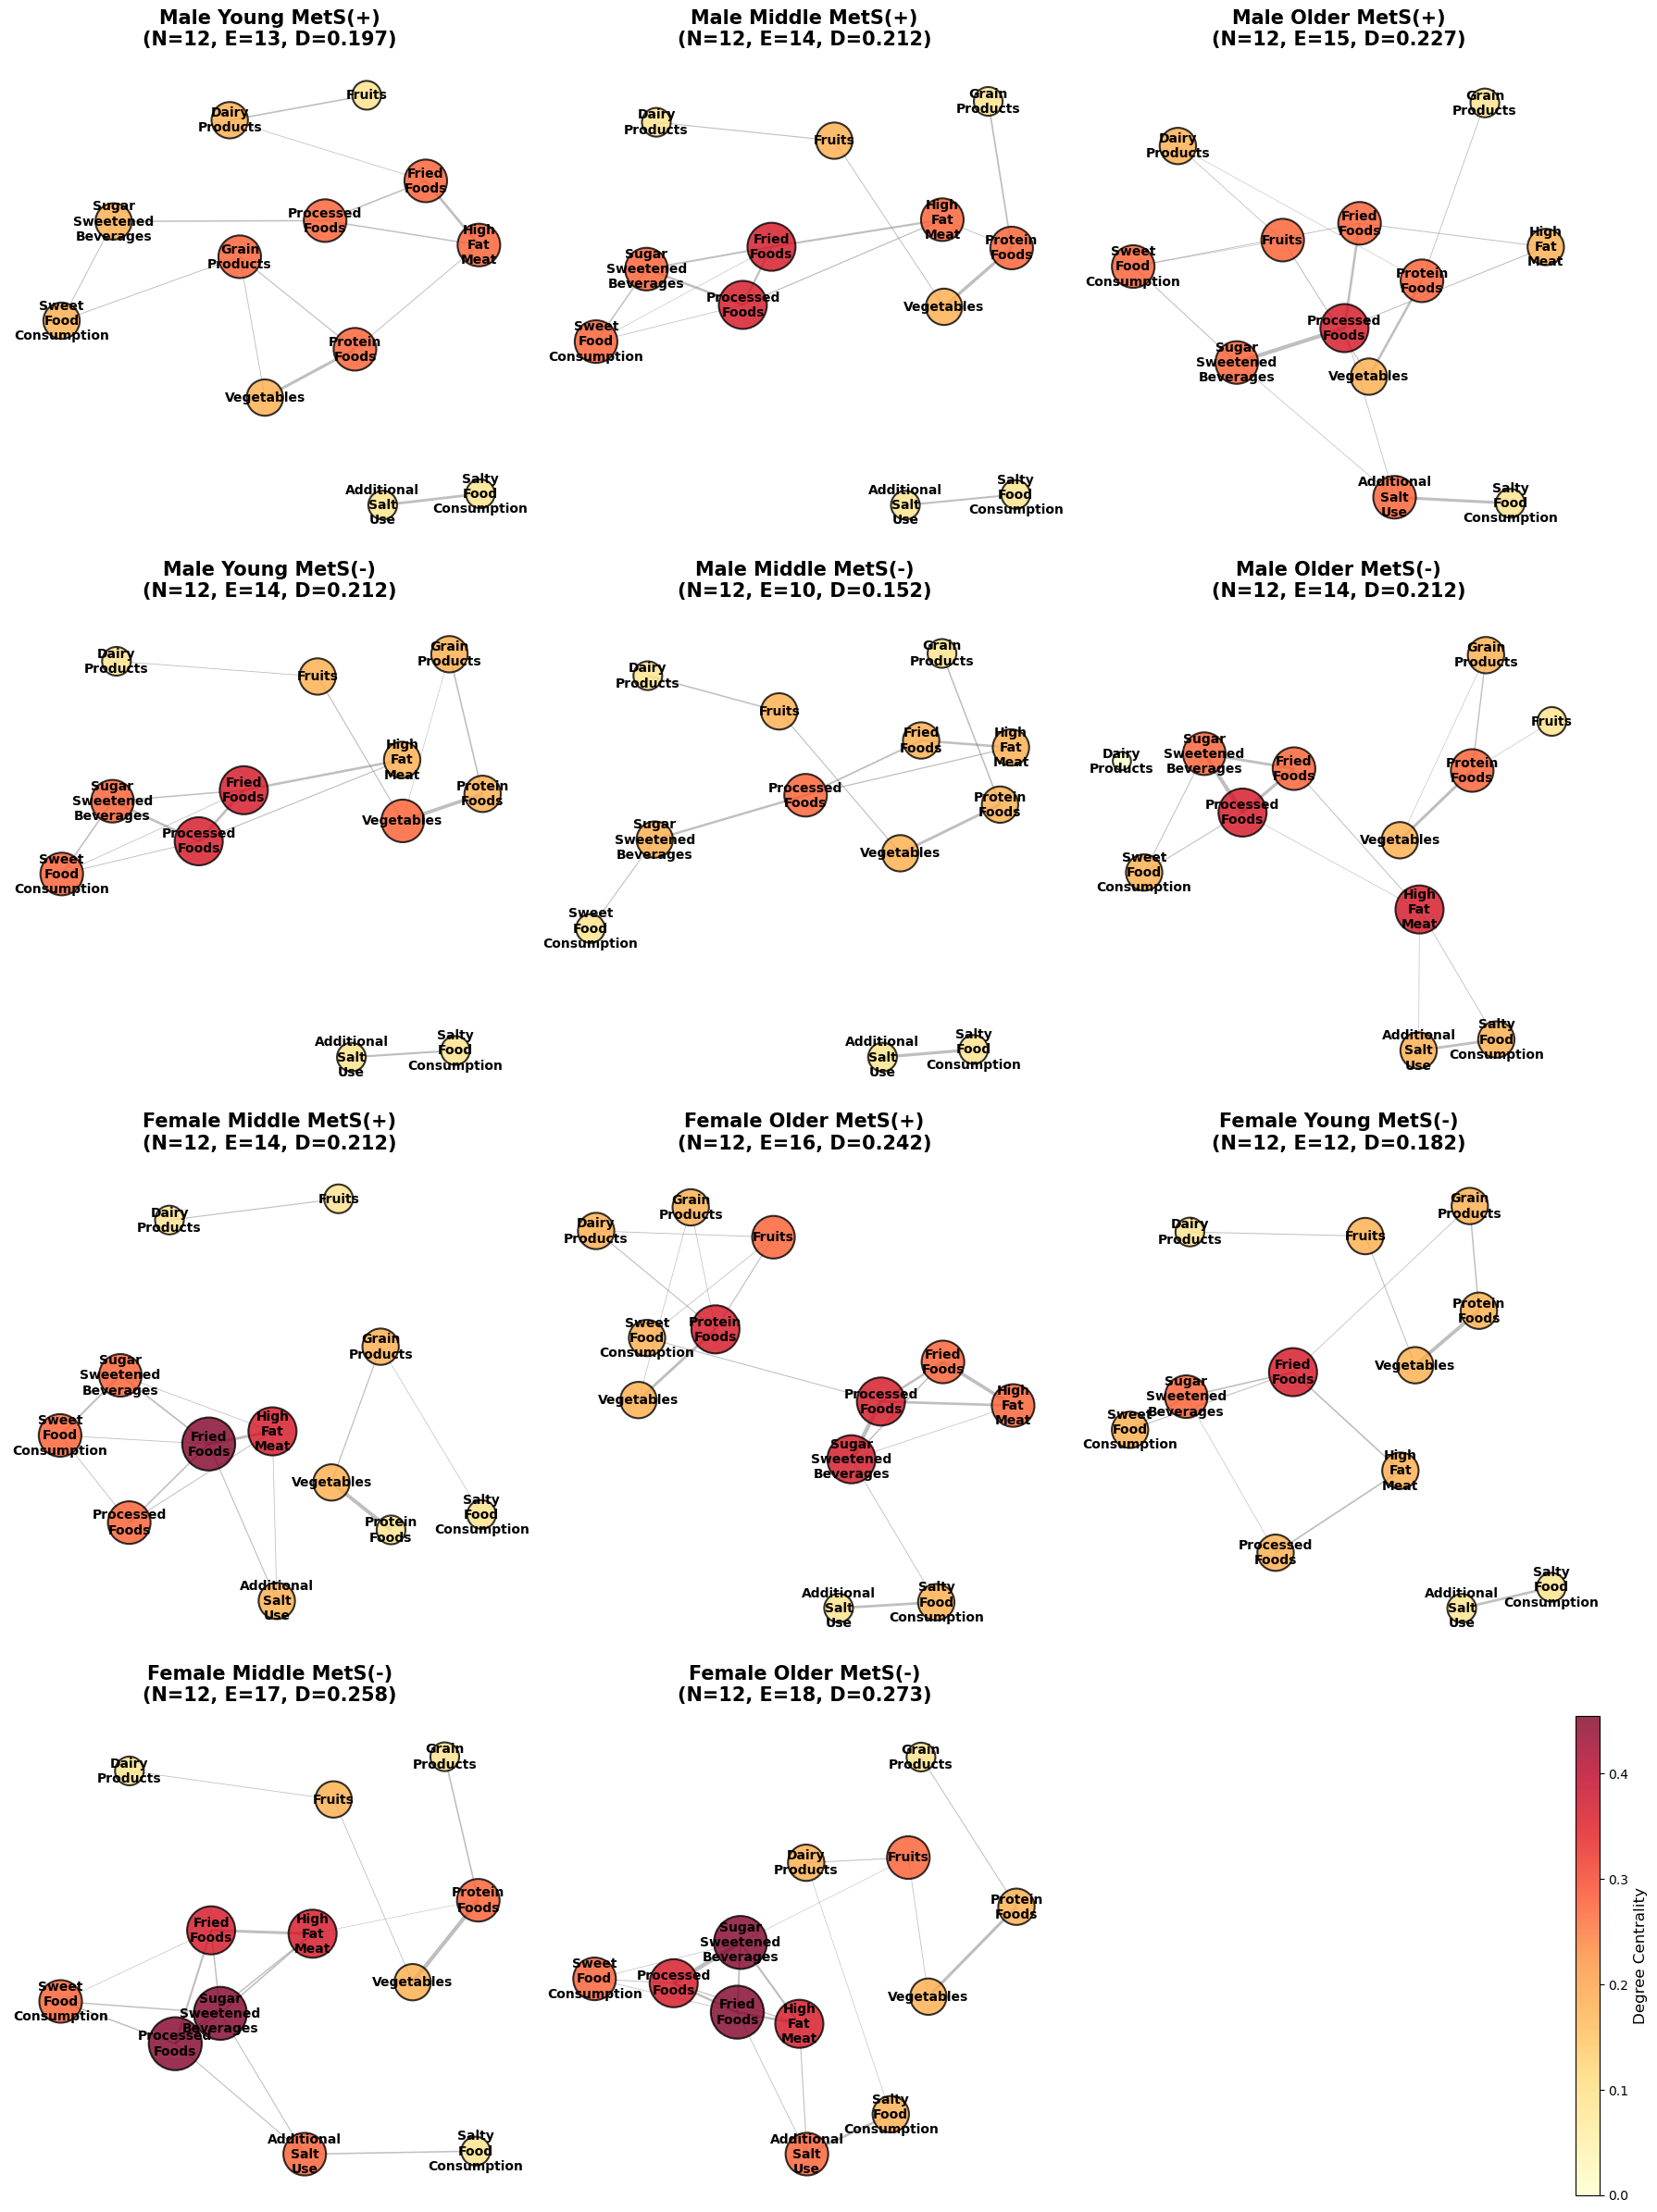

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

last_nodes = None
all_centralities = []

# Collect all centrality values
for sex, age_group, mets_status in GROUPS:
    G = load_network(sex, age_group, mets_status)
    if G is not None and G.number_of_nodes() > 0:
        centrality = nx.degree_centrality(G)
        all_centralities.extend(centrality.values())

# Calculate vmin/vmax from actual data
vmin = min(all_centralities) if all_centralities else 0
vmax = max(all_centralities) if all_centralities else 1
print(f"  Centrality range: {vmin:.3f} - {vmax:.3f}")

# Create network images
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(GROUP_LABELS[idx], fontsize=10, fontweight='bold')
        ax.axis('off')
        continue
    
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # Force-directed layout
    
    # Node sizes based on degree
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 300 + 200 for node in G.nodes()]
    
    # Node colors based on degree centrality
    centrality = nx.degree_centrality(G)
    node_colors = [centrality[node] for node in G.nodes()]
    
    # Draw edges with varying widths based on partial correlation
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 1.0)
        nx.draw_networkx_edges(
            G, pos, [(u, v)], 
            ax=ax, 
            alpha=0.5, 
            width=weight * 8,
            edge_color='gray'
        )
    
    # Draw nodes with adjusted vmin/vmax
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        alpha=0.8,
        edgecolors='black',
        linewidths=1.5
    )
    last_nodes = nodes
    
    # Draw labels with automatic line breaks
    labels = {}
    for node in G.nodes():
        label = node.replace(' ', '\n').replace('-', '\n')
        labels[node] = label

    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=10, font_weight='bold')
    
    ax.margins(0.1)

    # Title
    title = GROUP_LABELS[idx].replace('_', ' ')
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    
    ax.set_title(
        f"{title}\n(N={n_nodes}, E={n_edges}, D={density:.3f})",
        fontsize=15,
        fontweight='bold'
    )
    ax.axis('off')

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

# Add colorbar
if last_nodes is not None:
    cbar = plt.colorbar(last_nodes, ax=axes[-1], fraction=0.046, pad=0.04)
    cbar.set_label('Degree Centrality', fontsize=12)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_1_Network_Visualizations_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='none', transparent=True)
#plt.close()

## TABLE 2: Top Hub Foods by Group (Degree Centrality)

In [7]:
stats_df = load_statistics()
if stats_df is None:
    raise FileNotFoundError("Network statistics file not found!")

# Simplified Table 2: Focus on Hub Foods identification
hub_data = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    
    if G is None:
        continue
        
    group_label = GROUP_LABELS[idx]
    
    stats_row = stats_df[
        (stats_df['Sex'] == sex) & 
        (stats_df['Age_Group'] == age_group) & 
        (stats_df['MetS_Status'] == mets_status)
    ]
    
    if len(stats_row) == 0:
        continue
    
    stats_row = stats_row.iloc[0]
    
    # Calculate centralities
    degree_cent = nx.degree_centrality(G)
    
    # Get top 5 hub foods by degree centrality
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    
    row_data = {
        'Group': group_label,
        'N_Samples': int(stats_row['N_Samples']),
        'N_Nodes': G.number_of_nodes(),
        'N_Edges': G.number_of_edges(),
        'Density': f"{nx.density(G):.3f}",
    }
    
    # Add top 5 hubs
    for i, (food, centrality) in enumerate(top_hubs, 1):
        row_data[f'Hub_{i}'] = food
        row_data[f'Hub_{i}_Centrality'] = f"{centrality:.3f}"
    
    hub_data.append(row_data)

df_hubs = pd.DataFrame(hub_data)
df_hubs.to_csv(TABLES_DIR / 'Table_2_Hub_Foods_by_Group.csv', index=False)
print("Table 2: Top Hub Foods by Group")
df_hubs

Table 2: Top Hub Foods by Group


,Group,N_Samples,N_Nodes,N_Edges,Density,Hub_1,Hub_1_Centrality,Hub_2,Hub_2_Centrality,Hub_3,Hub_3_Centrality,Hub_4,Hub_4_Centrality,Hub_5,Hub_5_Centrality
0,Male_Young_MetS(+),516,12,13,0.197,Grain Products,0.273,Protein Foods,0.273,Fried Foods,0.273,High Fat Meat,0.273,Processed Foods,0.273
1,Male_Middle_MetS(+),2938,12,14,0.212,Fried Foods,0.364,Processed Foods,0.364,Protein Foods,0.273,High Fat Meat,0.273,Sugar-Sweetened Beverages,0.273
2,Male_Older_MetS(+),971,12,15,0.227,Processed Foods,0.364,Protein Foods,0.273,Fruits,0.273,Fried Foods,0.273,Sugar-Sweetened Beverages,0.273
3,Male_Young_MetS(-),4737,12,14,0.212,Fried Foods,0.364,Processed Foods,0.364,Vegetables,0.273,Sugar-Sweetened Beverages,0.273,Sweet Food Consumption,0.273
4,Male_Middle_MetS(-),1963,12,10,0.152,Processed Foods,0.273,Protein Foods,0.182,Vegetables,0.182,Fruits,0.182,Fried Foods,0.182
5,Male_Older_MetS(-),1169,12,14,0.212,High Fat Meat,0.364,Processed Foods,0.364,Protein Foods,0.273,Fried Foods,0.273,Sugar-Sweetened Beverages,0.273
6,Female_Middle_MetS(+),758,12,14,0.212,Fried Foods,0.455,High Fat Meat,0.364,Processed Foods,0.273,Sugar-Sweetened Beverages,0.273,Sweet Food Consumption,0.273
7,Female_Older_MetS(+),680,12,16,0.242,Protein Foods,0.364,Processed Foods,0.364,Sugar-Sweetened Beverages,0.364,Fruits,0.273,Fried Foods,0.273
8,Female_Young_MetS(-),2519,12,12,0.182,Fried Foods,0.364,Sugar-Sweetened Beverages,0.273,Grain Products,0.182,Protein Foods,0.182,Vegetables,0.182
9,Female_Middle_MetS(-),5629,12,17,0.258,Processed Foods,0.455,Sugar-Sweetened Beverages,0.455,Fried Foods,0.364,High Fat Meat,0.364,Protein Foods,0.273


## FIGURE 2: Hub Food Centrality Comparison

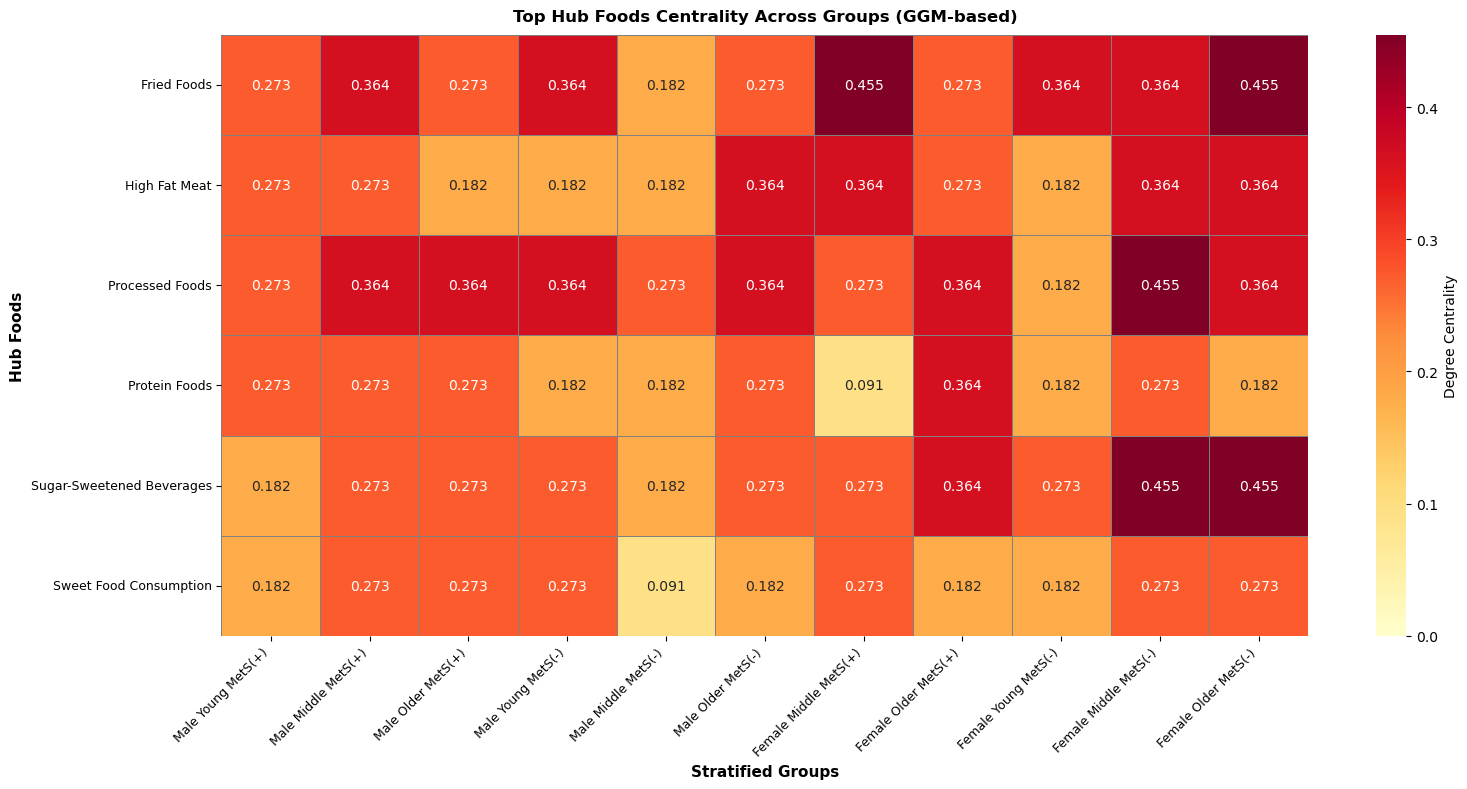

In [8]:
data = []
all_foods = set()

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    centrality = nx.degree_centrality(G)
    for food, cent_value in centrality.items():
        all_foods.add(food)
        data.append({
            'Group': GROUP_LABELS[idx].replace('_', ' '),
            'Food': food,
            'Centrality': cent_value
        })

df = pd.DataFrame(data)

# Top hub foods 선택
food_avg_centrality = df.groupby('Food')['Centrality'].mean().sort_values(ascending=False)
top_hub_foods = food_avg_centrality.head(6).index.tolist()

# 피벗 테이블 생성 (Food x Group)
df_top_hubs = df[df['Food'].isin(top_hub_foods)]
heatmap_data = df_top_hubs.pivot_table(
    index='Food', 
    columns='Group', 
    values='Centrality', 
    fill_value=0
)

# 그룹 순서 맞추기
group_labels_clean = [g.replace('_', ' ') for g in GROUP_LABELS]
heatmap_data = heatmap_data[group_labels_clean]

# 히트맵 그리기
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

import seaborn as sns
sns.heatmap(
    heatmap_data, 
    annot=True,  # 값 표시
    fmt='.3f',  # 소수점 3자리
    cmap='YlOrRd',  # 색상 맵
    cbar_kws={'label': 'Degree Centrality'},
    linewidths=0.5,  # 셀 구분선
    linecolor='gray',
    ax=ax,
    vmin=0,
    vmax=heatmap_data.values.max()
)

ax.set_xlabel('Stratified Groups', fontsize=11, fontweight='bold')
ax.set_ylabel('Hub Foods', fontsize=11, fontweight='bold')
ax.set_title('Top Hub Foods Centrality Across Groups (GGM-based)', fontsize=12, fontweight='bold', pad=10)

# X축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_2_Hub_Centrality_Comparison_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
#plt.close()


## TABLE S1: Network Edge List

In [9]:
all_edges = []

for sex, age_group, mets_status in GROUPS:
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_edges() == 0:
        continue
    
    group_label = f"{sex}_{age_group}_{mets_status}"
    
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 0)
        partial_corr = data.get('partial_corr', weight)
        
        all_edges.append({
            'Group': group_label,
            'Node 1': u,
            'Node 2': v,
            'Partial Correlation': f"{partial_corr:.4f}",
            'Absolute Weight': f"{weight:.4f}"
        })

df_edges = pd.DataFrame(all_edges)

output_file = TABLES_DIR / 'Supplementary_Table_S1_Edge_Lists_GGM.csv'
df_edges.to_csv(output_file, index=False)
df_edges.head()

,Group,Node 1,Node 2,Partial Correlation,Absolute Weight
0,남성_청년층(19-39세)_MetS(+),Grain Products,Protein Foods,0.1040,0.1040
1,남성_청년층(19-39세)_MetS(+),Grain Products,Vegetables,0.0802,0.0802
2,남성_청년층(19-39세)_MetS(+),Grain Products,Sweet Food Consumption,0.0867,0.0867
3,남성_청년층(19-39세)_MetS(+),Protein Foods,Vegetables,0.2766,0.2766
4,남성_청년층(19-39세)_MetS(+),Protein Foods,High Fat Meat,0.0876,0.0876


## TABLE S2: Community analysis

In [10]:
def categorize_foods(food_list):
    healthy = []
    processed = []
    salt_related = []
    
    for food in food_list:
        if food in ['Grain Products', 'Protein Foods', 'Vegetables', 'Dairy Products', 'Fruits']:
            healthy.append(food)
        elif food in ['Fried Foods', 'High Fat Meat', 'Processed Foods', 
                      'Sugar-Sweetened Beverages', 'Sweet Food Consumption']:
            processed.append(food)
        else:
            salt_related.append(food)
    
    return healthy, processed, salt_related

def interpret_community(foods):
    healthy, processed, salt_related = categorize_foods(foods)
    
    if len(healthy) >= len(processed) and len(healthy) >= len(salt_related):
        if len(healthy) >= 4:
            return "Traditional Korean Diet Pattern"
        else:
            return "Mixed Healthy Pattern"
    elif len(processed) > len(healthy) and len(processed) >= len(salt_related):
        if len(processed) >= 4:
            return "Western/Processed Food Pattern"
        else:
            return "Mixed Processed Pattern"
    elif len(salt_related) >= 2:
        return "High Sodium Pattern"
    else:
        return "Mixed Pattern"

summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')

all_rows = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    group = f"{sex}_{age_group}_{mets_status}"
    
    # Load community file
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    if not comm_file.exists():
        print(f"Warning: Community file not found: {comm_file}")
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    # Get modularity and n_communities
    modularity = summary_df[summary_df['Group'] == group]['Modularity'].values[0]
    n_communities = len(comm_df)
    group_english = GROUP_LABELS[idx]
    
    # Process each community
    for _, row in comm_df.iterrows():
        comm_id = row['community_id']
        size = row['size']
        nodes = row['nodes'].split('; ')
        internal_edges = row['internal_edges']
        internal_density = row['internal_density']
        
        # Categorize foods
        healthy, processed, salt_related = categorize_foods(nodes)
        interpretation = interpret_community(nodes)
        
        # Format food lists
        healthy_str = ', '.join(healthy) if healthy else '-'
        processed_str = ', '.join(processed) if processed else '-'
        salt_str = ', '.join(salt_related) if salt_related else '-'
        
        all_rows.append({
            'Group': group_english,
            'Total Communities': n_communities,
            'Modularity': f"{modularity:.3f}",
            'Community ID': comm_id,
            'Size': size,
            'Internal Edges': internal_edges,
            'Internal Density': f"{internal_density:.3f}",
            'Healthy Foods': healthy_str,
            'Processed/Unhealthy Foods': processed_str,
            'Salt-related Foods': salt_str,
            'Dietary Pattern': interpretation
        })

# Create DataFrame
table_df = pd.DataFrame(all_rows)
output_csv = TABLES_DIR / 'Supplementary_Table_S2_Community_Characteristics.csv'
table_df.to_csv(output_csv, index=False)
table_df.head()

,Group,Total Communities,Modularity,Community ID,Size,Internal Edges,Internal Density,Healthy Foods,Processed/Unhealthy Foods,Salt-related Foods,Dietary Pattern
0,Male_Young_MetS(+),5,0.539,1,2,1,1.000,-,"Sugar-Sweetened Beverages, Sweet Food Consumption",-,Mixed Processed Pattern
1,Male_Young_MetS(+),5,0.539,2,3,3,1.000,"Grain Products, Protein Foods, Vegetables",-,-,Mixed Healthy Pattern
2,Male_Young_MetS(+),5,0.539,3,2,1,1.000,"Dairy Products, Fruits",-,-,Mixed Healthy Pattern
3,Male_Young_MetS(+),5,0.539,4,3,3,1.000,-,"Fried Foods, High Fat Meat, Processed Foods",-,Mixed Processed Pattern
4,Male_Young_MetS(+),5,0.539,5,2,1,1.000,-,-,"Additional Salt Use, Salty Food Consumption",High Sodium Pattern


## FIGURE S1: Partial Correlation Heatmaps

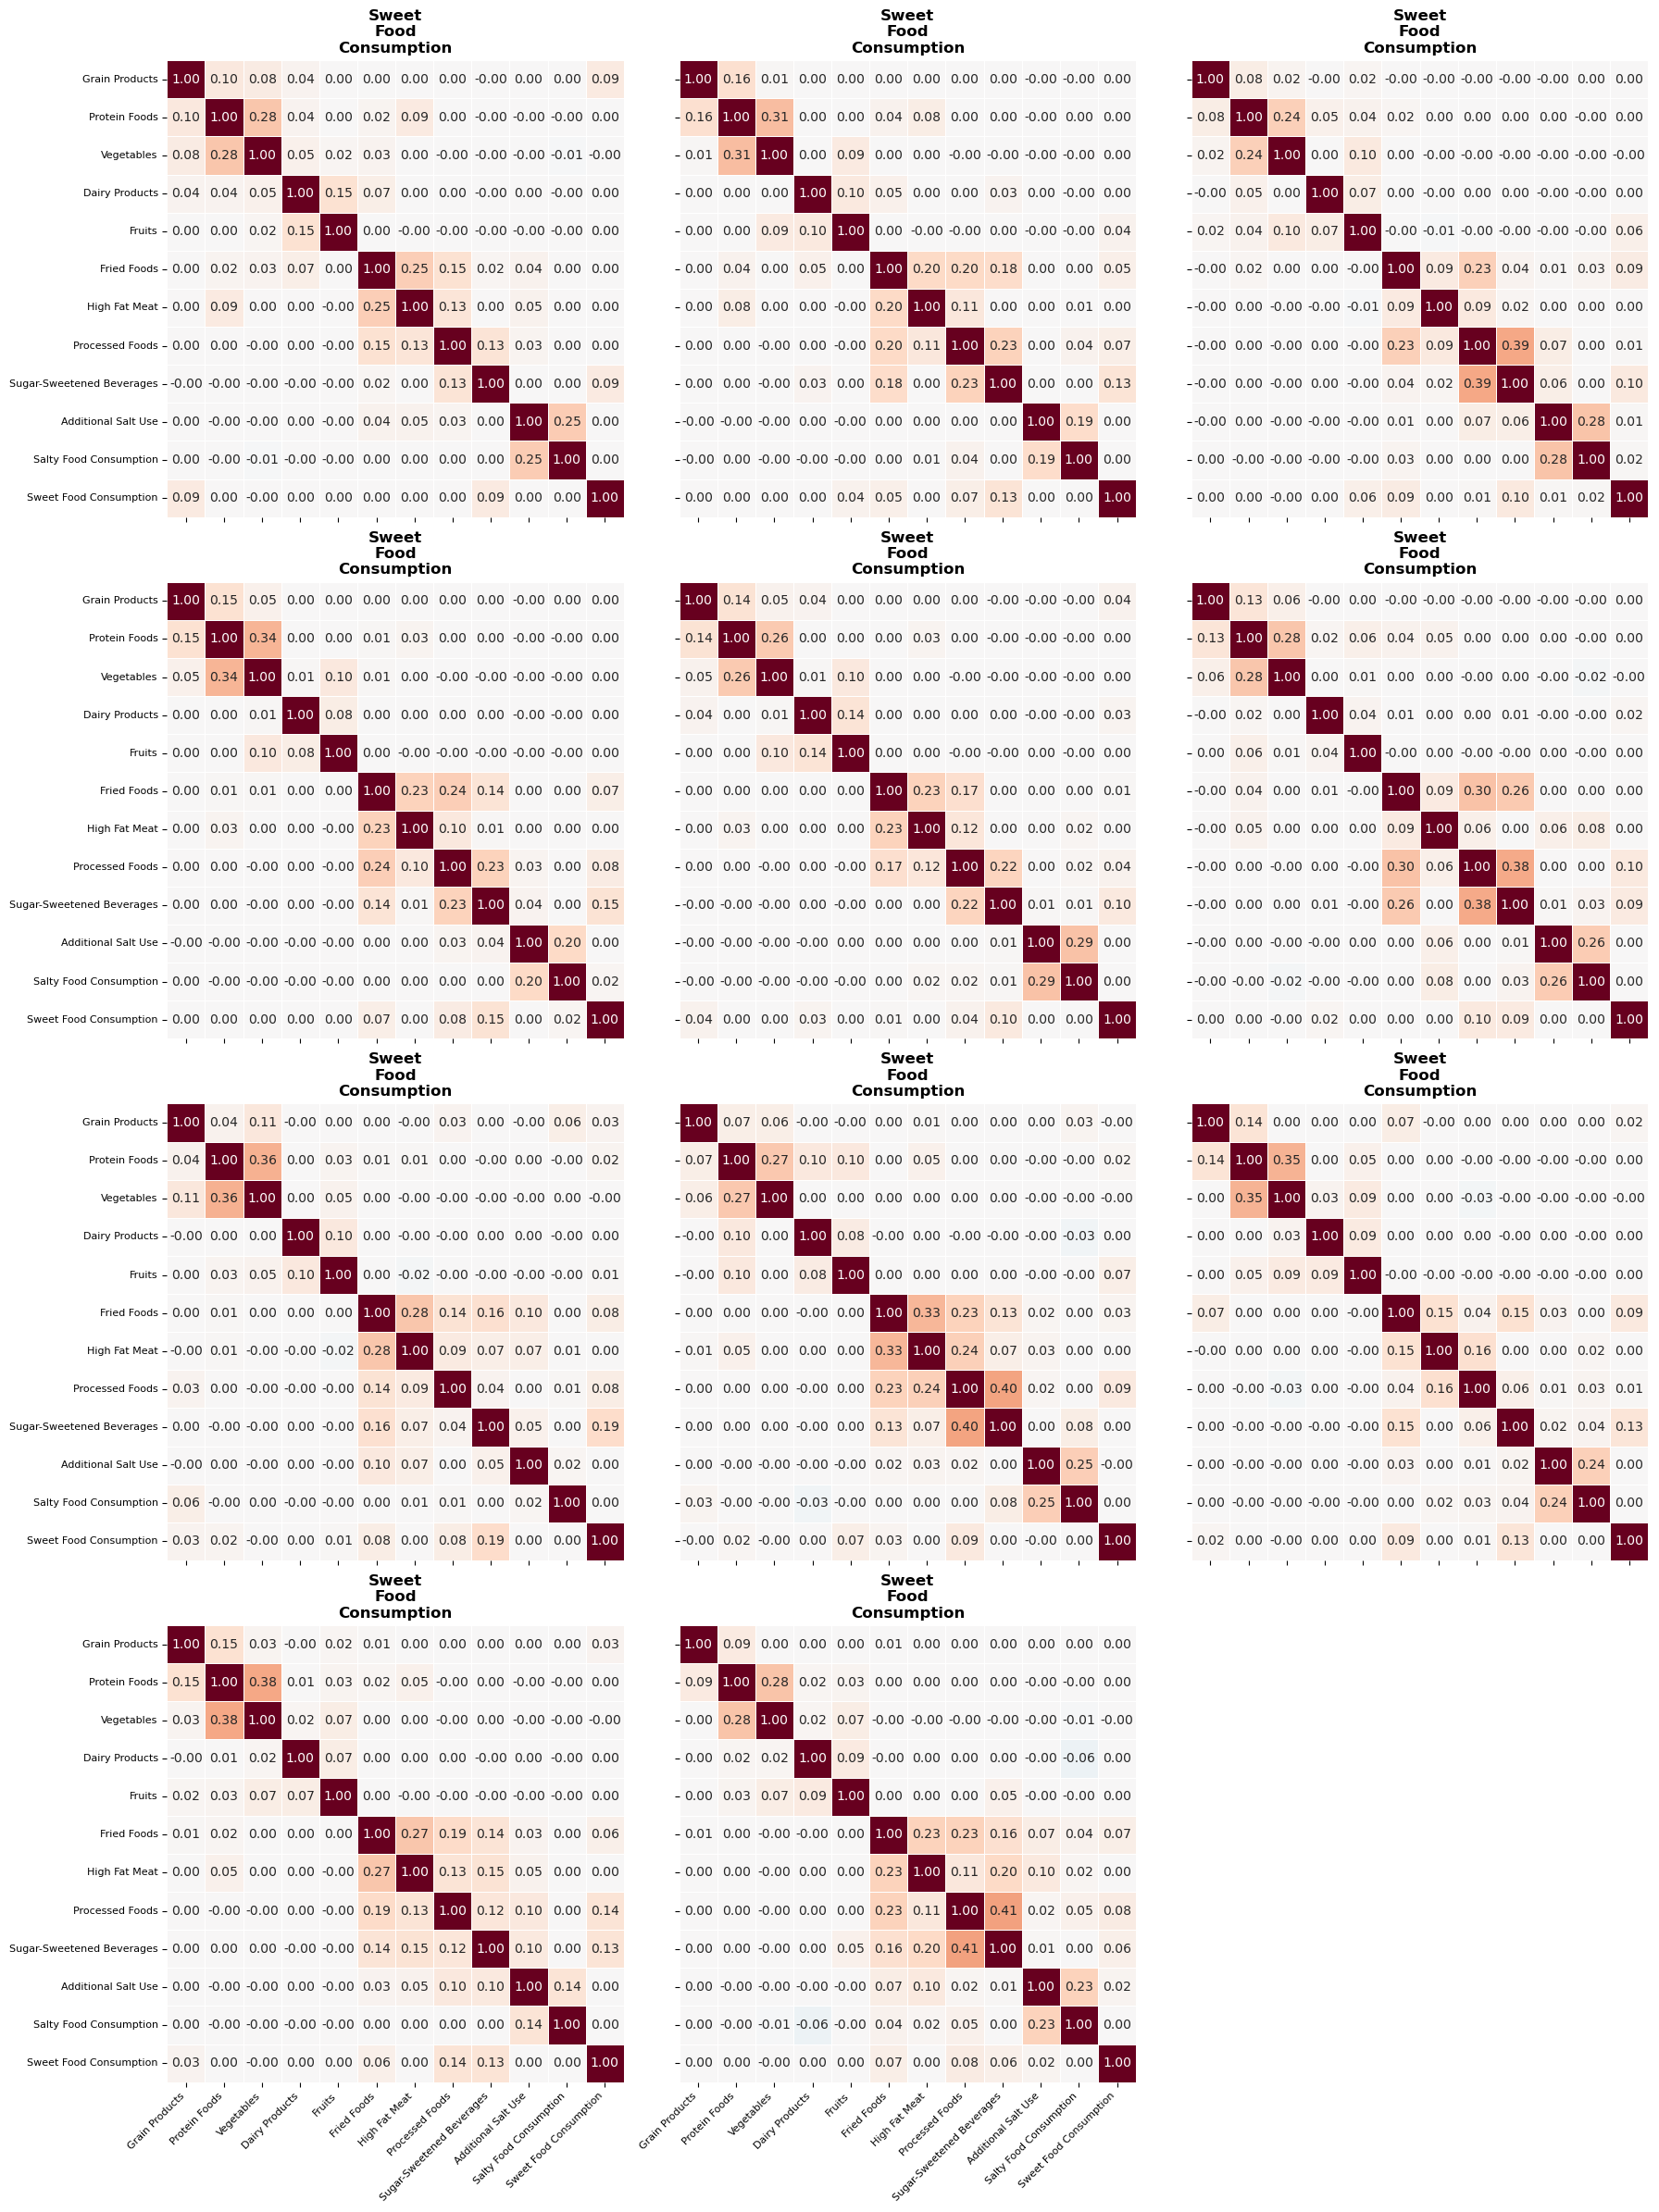

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    
    partial_corr_df = load_partial_corr_matrix(sex, age_group, mets_status)
    
    show_cbar = (idx == 12)
    
    sns.heatmap(
        partial_corr_df,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar=show_cbar,
        cbar_kws={'label': 'Partial Correlation'} if show_cbar else None,
        ax=ax,
        vmin=-1,
        vmax=1,
        square=True
    )
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for idx in range(9, 12):
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=8)
for idx in [0, 3, 6, 9]:
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
output_file = FIGURES_DIR / 'Supplementary_Figure_1_Partial_Correlation_Heatmaps_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

## FIGURE S2: Community Structure Analysis

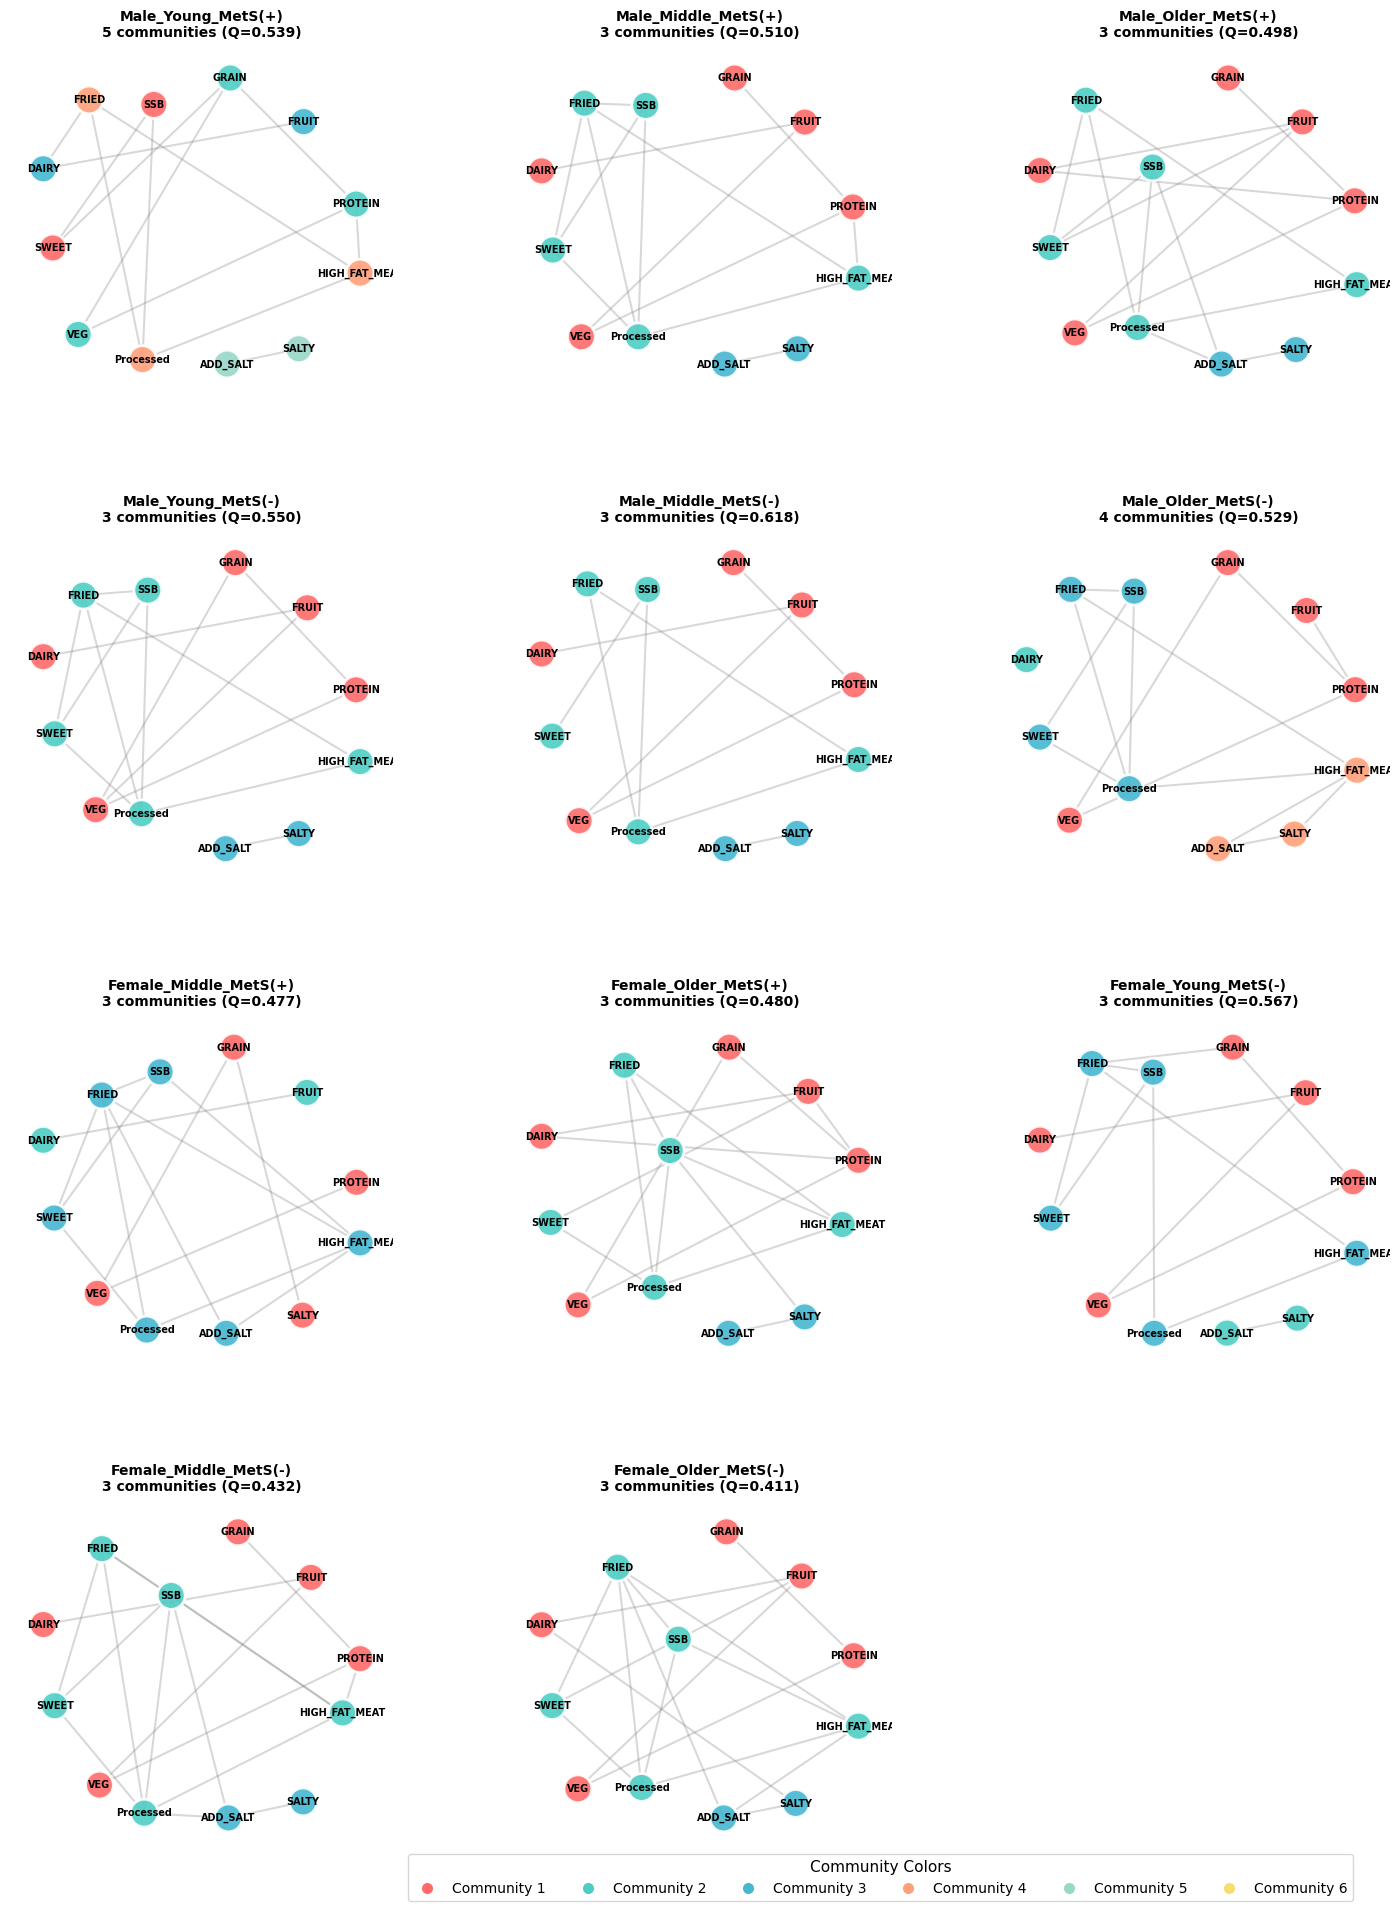

In [12]:
COMMUNITY_COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

summary_df = load_statistics()
fig = plt.figure(figsize=(15, 20))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3, left=0.05, right=0.97, top=0.95, bottom=0.05)

for idx, ((sex, age_group, mets_status), label) in enumerate(zip(GROUPS, GROUP_LABELS)):
    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    
    G = load_network(sex, age_group, mets_status)
    if G is None:
        ax.text(0.5, 0.5, 'Network\nNot Found', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        ax.axis('off')
        continue
    
    group = f"{sex}_{age_group}_{mets_status}"
    
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    if not comm_file.exists():
        print(f"  Warning: Community file not found: {comm_file}")
        ax.text(0.5, 0.5, 'Community\nData Missing', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        ax.axis('off')
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    # Create node-to-community mapping
    node_colors = {}
    for _, row_data in comm_df.iterrows():
        comm_id = row_data['community_id']
        nodes = row_data['nodes'].split('; ')
        color = COMMUNITY_COLORS[(comm_id - 1) % len(COMMUNITY_COLORS)]
        for node in nodes:
            node_colors[node] = color
    
    colors = [node_colors.get(node, '#CCCCCC') for node in G.nodes()]
    pos = nx.spring_layout(G, seed=42, k=1.5, iterations=50)
    
    # Draw network
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.5, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=400, alpha=0.9, edgecolors='white', linewidths=2)
    
    labels_dict = {node: FOOD_ABBREV.get(node, node[:4]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels_dict, ax=ax, font_size=7, font_weight='bold')
    
    # Title
    n_comm = len(comm_df)
    modularity = summary_df[summary_df['Group'] == group]['Modularity'].values[0]
    ax.set_title(f"{label}\n{n_comm} communities (Q={modularity:.3f})", 
                fontsize=10, fontweight='bold', pad=8)
    ax.axis('off')

# Add legend for community colors
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COMMUNITY_COLORS[i],
                markersize=10, label=f'Community {i+1}', 
                markeredgewidth=2, markeredgecolor='white')
    for i in range(6)
]
fig.legend(handles=legend_elements, loc='lower right', ncol=6,
            frameon=True, fontsize=10, bbox_to_anchor=(0.95, 0.02),
            title='Community Colors', title_fontsize=11)

# Save
output_file = FIGURES_DIR / 'Supplementary_Figure_2_Community_Structure.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

# 3.3. Mediating Role of Hub Foods on Dietary Patterns
* 허브 식품 High vs Low 그룹 간 다른 식품 섭취량 비교
* 이 허브를 조절하면 어떤 식품들이 같이 조절되는가

## TABLE 3: Mediating Role of Hub Foods on Other Food Intakes

This table shows how controlling hub foods (High vs Low intake) affects the consumption of other foods.
- Hub_Food: The identified hub food from network analysis
- Compared_Food: Other foods whose intake differs between High/Low hub food groups
- Difference: Mean difference in intake (High - Low)
- P_Value: Statistical significance (Mann-Whitney U test)
- Interpretation: "When this hub is high, these foods are also high/low"

In [13]:
# TABLE 3: Mediating Role of Hub Foods on Dietary Patterns
# Compare food intake between High vs Low hub food groups

df_raw = load_raw_data()

# Foods to analyze
foods_to_analyze = ['Fried Foods', 'Processed Foods', 'Sugar-Sweetened Beverages', 
                    'High Fat Meat', 'Vegetables', 'Fruits', 'Protein Foods', 'Grain Products']

def assign_tertile_group(data, food_col):
    """Assign Low/High groups based on tertiles or median"""
    p33, p67 = data[food_col].quantile([0.33, 0.67])
    
    if p33 == p67:  # Use median split
        median_val = data[food_col].median()
        return data[food_col].apply(lambda x: 'Low' if x <= median_val else 'High'), 'binary'
    
    def assign(x):
        return 'Low' if x <= p33 else ('Medium' if x <= p67 else 'High')
    tertiles = data[food_col].apply(assign)
    
    if len(tertiles.value_counts()) < 3:
        median_val = data[food_col].median()
        return data[food_col].apply(lambda x: 'Low' if x <= median_val else 'High'), 'binary'
    return tertiles, 'tertile'

all_results = []

# Analyze each group
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    group_label = GROUP_LABELS[idx]
    
    # Get hub foods for this group
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    degree_cent = nx.degree_centrality(G)
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Filter data for this group
    mask = (df_raw['Sex'] == SEX_REVERSE[sex]) & \
           (df_raw['Age_Group'] == age_group) & \
           (df_raw['MetS_Status'] == mets_status)
    group_data = df_raw[mask].copy()
    
    if len(group_data) < 30:
        continue
    
    # Analyze each hub food
    for hub_food, hub_centrality in top_hubs:
        if hub_food not in group_data.columns or group_data[hub_food].nunique() < 2:
            continue
        
        try:
            group_data['Tertile'], split_method = assign_tertile_group(group_data, hub_food)
            low_data = group_data[group_data['Tertile'] == 'Low']
            high_data = group_data[group_data['Tertile'] == 'High']
            
            if len(low_data) < 10 or len(high_data) < 10:
                continue
            
            # Compare other foods
            for food in foods_to_analyze:
                if food == hub_food or food not in group_data.columns:
                    continue
                
                stat, p_value = stats.mannwhitneyu(low_data[food], high_data[food], 
                                                   alternative='two-sided')
                
                all_results.append({
                    'Group': group_label,
                    'MetS_Status': mets_status,
                    'Hub_Food': hub_food,
                    'Hub_Centrality': f"{hub_centrality:.3f}",
                    'Split_Method': split_method,
                    'Compared_Food': food,
                    'N_Low': len(low_data),
                    'N_High': len(high_data),
                    'Low_Mean': round(low_data[food].mean(), 3),
                    'High_Mean': round(high_data[food].mean(), 3),
                    'Difference': round(high_data[food].mean() - low_data[food].mean(), 3),
                    'P_Value': round(p_value, 4),
                    'Significant': '***' if p_value < 0.001 else 
                                  '**' if p_value < 0.01 else 
                                  '*' if p_value < 0.05 else 'ns'
                })
        except Exception as e:
            print(f"Error processing {group_label} - {hub_food}: {e}")
            continue

df_tertile = pd.DataFrame(all_results)
df_tertile.to_csv(TABLES_DIR / 'Table_3_Mediating_Role_of_Hubs.csv', index=False)

print("Table 3: Mediating Role of Hub Foods")
print(f"Total comparisons: {len(df_tertile)}")
print(f"Significant associations (p<0.05): {len(df_tertile[df_tertile['P_Value'] < 0.05])}")
print("\nSample results:")
df_tertile.head(20)

Table 3: Mediating Role of Hub Foods
Total comparisons: 224
Significant associations (p<0.05): 155

Sample results:


,Group,MetS_Status,Hub_Food,Hub_Centrality,Split_Method,Compared_Food,N_Low,N_High,Low_Mean,High_Mean,Difference,P_Value,Significant
0,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Fried Foods,432,84,1.674,1.893,0.219,0.0122,*
1,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Processed Foods,432,84,1.787,1.845,0.058,0.3263,ns
2,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Sugar-Sweetened Beverages,432,84,1.979,1.929,-0.051,0.7680,ns
3,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,High Fat Meat,432,84,1.954,2.071,0.118,0.1772,ns
4,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Vegetables,432,84,2.475,3.036,0.561,0.0000,***
5,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Fruits,432,84,1.500,1.690,0.190,0.0254,*
6,Male_Young_MetS(+),MetS(+),Grain Products,0.273,binary,Protein Foods,432,84,3.106,3.536,0.429,0.0000,***
7,Male_Young_MetS(+),MetS(+),Protein Foods,0.273,binary,Fried Foods,325,191,1.622,1.859,0.237,0.0009,***
8,Male_Young_MetS(+),MetS(+),Protein Foods,0.273,binary,Processed Foods,325,191,1.772,1.838,0.065,0.4878,ns
9,Male_Young_MetS(+),MetS(+),Protein Foods,0.273,binary,Sugar-Sweetened Beverages,325,191,1.985,1.948,-0.037,0.4846,ns


# 3.4. Association Between Hub Foods and Health Outcomes

Goal: Understand how hub food intake relates to health indicators
- **3.4.1**: In MetS(-) groups → Prevention perspective (risk factors)
- **3.4.2**: In MetS(+) groups → Management perspective (severity)

## 3.4.1. Prevention Perspective (MetS- Groups)

**Research Question**: Among healthy individuals (MetS-), which hub foods are associated with better/worse health indicators?

**Analysis**: Compare health indicators between High vs Low intake of each hub food
- BMI, Waist Circumference
- Blood Pressure (SBP, DBP)
- Fasting Glucose
- Triglycerides, HDL
- Number of MetS risk factors (0-4 components present but not meeting MetS criteria)

### TABLE 4: Hub Foods and Health Indicators in MetS(-) Groups (Prevention)

In [14]:
# TABLE 4: Prevention Perspective - Hub Foods and Health Indicators in MetS(-) Groups

df_raw = load_raw_data()

# Health indicators to analyze (using correct column names)
health_indicators = ['BMI(kg/m2)', 'Waist circumference (cm)', 
                     'Systolic blood pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)', 
                     'Fasting glucose (mg/dL)', 'Triglycerides (mg/dL)', 'HDL-C (mg/dL)']

# Count MetS risk factors (0-4 components in MetS- individuals)
def count_risk_factors(row):
    """Count number of MetS components present (even if not meeting full MetS criteria)"""
    count = 0
    # Waist circumference
    if (row['Sex'] == 'M' and row['Waist circumference (cm)'] >= 90) or \
       (row['Sex'] == 'F' and row['Waist circumference (cm)'] >= 85):
        count += 1
    # Blood pressure
    if row['Systolic blood pressure (mmHg)'] >= 130 or row['Diastolic Blood Pressure (mmHg)'] >= 85:
        count += 1
    # Fasting glucose
    if row['Fasting glucose (mg/dL)'] >= 100:
        count += 1
    # Triglycerides
    if row['Triglycerides (mg/dL)'] >= 150:
        count += 1
    # HDL
    if (row['Sex'] == 'M' and row['HDL-C (mg/dL)'] < 40) or (row['Sex'] == 'F' and row['HDL-C (mg/dL)'] < 50):
        count += 1
    return count

df_raw['N_Risk_Factors'] = df_raw.apply(count_risk_factors, axis=1)

prevention_results = []

# Analyze only MetS(-) groups
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    if mets_status != 'MetS(-)':
        continue
    
    group_label = GROUP_LABELS[idx]
    
    # Get hub foods for this group
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    degree_cent = nx.degree_centrality(G)
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Filter data for this group
    mask = (df_raw['Sex'] == SEX_REVERSE[sex]) & \
           (df_raw['Age_Group'] == age_group) & \
           (df_raw['MetS_Status'] == 'MetS(-)')
    group_data = df_raw[mask].copy()
    
    if len(group_data) < 30:
        continue
    
    # Analyze each hub food
    for hub_food, hub_centrality in top_hubs:
        if hub_food not in group_data.columns or group_data[hub_food].nunique() < 2:
            continue
        
        # Split into tertiles (or binary if not enough variation)
        try:
            p33, p67 = group_data[hub_food].quantile([0.33, 0.67])
            
            if p33 == p67:  # Use median split
                median_val = group_data[hub_food].median()
                group_data['Hub_Group'] = group_data[hub_food].apply(
                    lambda x: 'Low' if x <= median_val else 'High'
                )
            else:  # Use tertiles, compare Low vs High only
                def assign_tertile(x):
                    if x <= p33:
                        return 'Low'
                    elif x > p67:
                        return 'High'
                    else:
                        return 'Medium'
                group_data['Hub_Group'] = group_data[hub_food].apply(assign_tertile)
            
            low_group = group_data[group_data['Hub_Group'] == 'Low']
            high_group = group_data[group_data['Hub_Group'] == 'High']
            
            if len(low_group) < 10 or len(high_group) < 10:
                continue
            
            # Compare health indicators
            for indicator in health_indicators + ['N_Risk_Factors']:
                if indicator not in group_data.columns:
                    continue
                
                low_mean = low_group[indicator].mean()
                high_mean = high_group[indicator].mean()
                diff = high_mean - low_mean
                
                # Statistical test
                stat, p_value = stats.mannwhitneyu(
                    low_group[indicator], 
                    high_group[indicator], 
                    alternative='two-sided'
                )
                
                # Determine direction
                if p_value < 0.05:
                    if diff > 0:
                        direction = 'Risk' if indicator != 'HDL-C (mg/dL)' else 'Protective'
                    else:
                        direction = 'Protective' if indicator != 'HDL-C (mg/dL)' else 'Risk'
                else:
                    direction = 'No association'
                
                prevention_results.append({
                    'Group': group_label,
                    'Hub_Food': hub_food,
                    'Hub_Centrality': f"{hub_centrality:.3f}",
                    'Health_Indicator': indicator,
                    'N_Low': len(low_group),
                    'N_High': len(high_group),
                    'Low_Mean': f"{low_mean:.2f}",
                    'High_Mean': f"{high_mean:.2f}",
                    'Difference': f"{diff:.2f}",
                    'P_Value': f"{p_value:.4f}",
                    'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns',
                    'Direction': direction
                })
        
        except Exception as e:
            print(f"Error processing {group_label} - {hub_food}: {e}")
            continue

df_prevention = pd.DataFrame(prevention_results)
df_prevention.to_csv(TABLES_DIR / 'Table_4_Prevention_Hub_Health_Association.csv', index=False)

# Summary: Classify hub foods as Risk or Protective
summary_data = []
for group in df_prevention['Group'].unique():
    group_data = df_prevention[(df_prevention['Group'] == group) & (df_prevention['P_Value'].astype(float) < 0.05)]
    
    for hub in group_data['Hub_Food'].unique():
        hub_data = group_data[group_data['Hub_Food'] == hub]
        
        n_risk = len(hub_data[hub_data['Direction'] == 'Risk'])
        n_protective = len(hub_data[hub_data['Direction'] == 'Protective'])
        
        if n_risk > n_protective:
            classification = 'Risk Factor'
        elif n_protective > n_risk:
            classification = 'Protective Factor'
        else:
            classification = 'Mixed'
        
        summary_data.append({
            'Group': group,
            'Hub_Food': hub,
            'N_Significant_Associations': len(hub_data),
            'N_Risk_Indicators': n_risk,
            'N_Protective_Indicators': n_protective,
            'Classification': classification
        })

df_prevention_summary = pd.DataFrame(summary_data)
df_prevention_summary.to_csv(TABLES_DIR / 'Table_4_Summary_Prevention_Classification.csv', index=False)

print("Table 4: Hub Foods and Health Indicators in MetS(-) Groups")
print("\nDetailed Results:")
print(df_prevention.head(20).to_string(index=False))
print("\n" + "="*80)
print("\nSummary - Hub Food Classification:")
df_prevention_summary

Table 4: Hub Foods and Health Indicators in MetS(-) Groups

Detailed Results:
             Group        Hub_Food Hub_Centrality                Health_Indicator  N_Low  N_High Low_Mean High_Mean Difference P_Value Significant      Direction
Male_Young_MetS(-)     Fried Foods          0.364                      BMI(kg/m2)   3271    1466    23.82     24.09       0.27  0.0043          **           Risk
Male_Young_MetS(-)     Fried Foods          0.364        Waist circumference (cm)   3271    1466    85.75     86.87       1.12  0.0000         ***           Risk
Male_Young_MetS(-)     Fried Foods          0.364  Systolic blood pressure (mmHg)   3271    1466   117.43    117.78       0.34  0.1601          ns No association
Male_Young_MetS(-)     Fried Foods          0.364 Diastolic Blood Pressure (mmHg)   3271    1466    78.00     77.98      -0.02  0.9643          ns No association
Male_Young_MetS(-)     Fried Foods          0.364         Fasting glucose (mg/dL)   3271    1466    98.89     98

,Group,Hub_Food,N_Significant_Associations,N_Risk_Indicators,N_Protective_Indicators,Classification
0,Male_Young_MetS(-),Fried Foods,2,2,0,Risk Factor
1,Male_Young_MetS(-),Processed Foods,3,3,0,Risk Factor
2,Male_Young_MetS(-),Vegetables,4,0,4,Protective Factor
3,Male_Middle_MetS(-),Processed Foods,3,3,0,Risk Factor
4,Male_Middle_MetS(-),Vegetables,1,0,1,Protective Factor
5,Male_Older_MetS(-),High Fat Meat,1,0,1,Protective Factor
6,Male_Older_MetS(-),Processed Foods,1,0,1,Protective Factor
7,Male_Older_MetS(-),Protein Foods,2,0,2,Protective Factor
8,Female_Young_MetS(-),Fried Foods,1,1,0,Risk Factor
9,Female_Young_MetS(-),Sugar-Sweetened Beverages,3,3,0,Risk Factor


## 3.4.2. Management Perspective (MetS+ Groups)

**Research Question**: Among MetS patients (MetS+), which hub foods are associated with more/less severe MetS?

**Analysis**: Compare MetS severity between High vs Low intake of each hub food
- Number of MetS components (3-5)
- Severity of each component (how far from threshold)

### TABLE 5: Hub Foods and MetS Severity in MetS(+) Groups (Management)

In [15]:
# TABLE 5: Management Perspective - Hub Foods and MetS Severity in MetS(+) Groups

# Health indicators (using correct column names)
health_indicators = ['BMI(kg/m2)', 'Waist circumference (cm)', 
                     'Systolic blood pressure (mmHg)', 'Diastolic Blood Pressure (mmHg)', 
                     'Fasting glucose (mg/dL)', 'Triglycerides (mg/dL)', 'HDL-C (mg/dL)']

# Count total MetS components (3-5 for MetS+ individuals)
def count_mets_components(row):
    """Count number of MetS components present (3-5 for MetS+ patients)"""
    count = 0
    # Waist circumference
    if (row['Sex'] == 'M' and row['Waist circumference (cm)'] >= 90) or \
       (row['Sex'] == 'F' and row['Waist circumference (cm)'] >= 85):
        count += 1
    # Blood pressure
    if row['Systolic blood pressure (mmHg)'] >= 130 or row['Diastolic Blood Pressure (mmHg)'] >= 85:
        count += 1
    # Fasting glucose
    if row['Fasting glucose (mg/dL)'] >= 100:
        count += 1
    # Triglycerides
    if row['Triglycerides (mg/dL)'] >= 150:
        count += 1
    # HDL
    if (row['Sex'] == 'M' and row['HDL-C (mg/dL)'] < 40) or (row['Sex'] == 'F' and row['HDL-C (mg/dL)'] < 50):
        count += 1
    return count

df_raw['N_MetS_Components'] = df_raw.apply(count_mets_components, axis=1)

management_results = []

# Analyze only MetS(+) groups
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    if mets_status != 'MetS(+)':
        continue
    
    group_label = GROUP_LABELS[idx]
    
    # Get hub foods for this group
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    degree_cent = nx.degree_centrality(G)
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Filter data for this group
    mask = (df_raw['Sex'] == SEX_REVERSE[sex]) & \
           (df_raw['Age_Group'] == age_group) & \
           (df_raw['MetS_Status'] == 'MetS(+)')
    group_data = df_raw[mask].copy()
    
    if len(group_data) < 30:
        continue
    
    # Analyze each hub food
    for hub_food, hub_centrality in top_hubs:
        if hub_food not in group_data.columns or group_data[hub_food].nunique() < 2:
            continue
        
        # Split into tertiles (or binary if not enough variation)
        try:
            p33, p67 = group_data[hub_food].quantile([0.33, 0.67])
            
            if p33 == p67:  # Use median split
                median_val = group_data[hub_food].median()
                group_data['Hub_Group'] = group_data[hub_food].apply(
                    lambda x: 'Low' if x <= median_val else 'High'
                )
            else:  # Use tertiles, compare Low vs High only
                def assign_tertile(x):
                    if x <= p33:
                        return 'Low'
                    elif x > p67:
                        return 'High'
                    else:
                        return 'Medium'
                group_data['Hub_Group'] = group_data[hub_food].apply(assign_tertile)
            
            low_group = group_data[group_data['Hub_Group'] == 'Low']
            high_group = group_data[group_data['Hub_Group'] == 'High']
            
            if len(low_group) < 10 or len(high_group) < 10:
                continue
            
            # Compare MetS severity indicators
            severity_indicators = health_indicators + ['N_MetS_Components']
            
            for indicator in severity_indicators:
                if indicator not in group_data.columns:
                    continue
                
                low_mean = low_group[indicator].mean()
                high_mean = high_group[indicator].mean()
                diff = high_mean - low_mean
                
                # Statistical test
                stat, p_value = stats.mannwhitneyu(
                    low_group[indicator], 
                    high_group[indicator], 
                    alternative='two-sided'
                )
                
                # Determine direction (aggravating vs alleviating)
                if p_value < 0.05:
                    if diff > 0:
                        direction = 'Aggravating' if indicator != 'HDL-C (mg/dL)' else 'Alleviating'
                    else:
                        direction = 'Alleviating' if indicator != 'HDL-C (mg/dL)' else 'Aggravating'
                else:
                    direction = 'No association'
                
                management_results.append({
                    'Group': group_label,
                    'Hub_Food': hub_food,
                    'Hub_Centrality': f"{hub_centrality:.3f}",
                    'Severity_Indicator': indicator,
                    'N_Low': len(low_group),
                    'N_High': len(high_group),
                    'Low_Mean': f"{low_mean:.2f}",
                    'High_Mean': f"{high_mean:.2f}",
                    'Difference': f"{diff:.2f}",
                    'P_Value': f"{p_value:.4f}",
                    'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns',
                    'Direction': direction
                })
        
        except Exception as e:
            print(f"Error processing {group_label} - {hub_food}: {e}")
            continue

df_management = pd.DataFrame(management_results)
df_management.to_csv(TABLES_DIR / 'Table_5_Management_Hub_Severity_Association.csv', index=False)

# Summary: Classify hub foods as Aggravating or Alleviating
summary_data = []
for group in df_management['Group'].unique():
    group_data = df_management[(df_management['Group'] == group) & (df_management['P_Value'].astype(float) < 0.05)]
    
    for hub in group_data['Hub_Food'].unique():
        hub_data = group_data[group_data['Hub_Food'] == hub]
        
        n_aggravating = len(hub_data[hub_data['Direction'] == 'Aggravating'])
        n_alleviating = len(hub_data[hub_data['Direction'] == 'Alleviating'])
        
        if n_aggravating > n_alleviating:
            classification = 'Aggravating Factor'
        elif n_alleviating > n_aggravating:
            classification = 'Alleviating Factor'
        else:
            classification = 'Mixed'
        
        summary_data.append({
            'Group': group,
            'Hub_Food': hub,
            'N_Significant_Associations': len(hub_data),
            'N_Aggravating_Effects': n_aggravating,
            'N_Alleviating_Effects': n_alleviating,
            'Classification': classification
        })

df_management_summary = pd.DataFrame(summary_data)
df_management_summary.to_csv(TABLES_DIR / 'Table_5_Summary_Management_Classification.csv', index=False)

print("Table 5: Hub Foods and MetS Severity in MetS(+) Groups")
print("\nDetailed Results:")
print(df_management.head(20).to_string(index=False))
print("\n" + "="*80)
print("\nSummary - Hub Food Classification:")
df_management_summary

Table 5: Hub Foods and MetS Severity in MetS(+) Groups

Detailed Results:
              Group       Hub_Food Hub_Centrality              Severity_Indicator  N_Low  N_High Low_Mean High_Mean Difference P_Value Significant      Direction
 Male_Young_MetS(+) Grain Products          0.273                      BMI(kg/m2)    432      84    28.55     28.15      -0.40  0.3095          ns No association
 Male_Young_MetS(+) Grain Products          0.273        Waist circumference (cm)    432      84    97.78     97.24      -0.54  0.6045          ns No association
 Male_Young_MetS(+) Grain Products          0.273  Systolic blood pressure (mmHg)    432      84   128.90    128.23      -0.68  0.9939          ns No association
 Male_Young_MetS(+) Grain Products          0.273 Diastolic Blood Pressure (mmHg)    432      84    84.22     83.01      -1.21  0.3483          ns No association
 Male_Young_MetS(+) Grain Products          0.273         Fasting glucose (mg/dL)    432      84   104.91    105.58 

,Group,Hub_Food,N_Significant_Associations,N_Aggravating_Effects,N_Alleviating_Effects,Classification
0,Male_Young_MetS(+),Grain Products,2,2,0,Aggravating Factor
1,Male_Middle_MetS(+),Fried Foods,4,2,2,Mixed
2,Male_Middle_MetS(+),Processed Foods,3,3,0,Aggravating Factor
3,Male_Middle_MetS(+),Protein Foods,2,2,0,Aggravating Factor
4,Male_Older_MetS(+),Processed Foods,2,2,0,Aggravating Factor
5,Female_Middle_MetS(+),Fried Foods,4,4,0,Aggravating Factor
6,Female_Middle_MetS(+),Processed Foods,1,1,0,Aggravating Factor
7,Female_Older_MetS(+),Protein Foods,1,0,1,Alleviating Factor


# 3.5. Integrated Dietary Strategy Based on Hub Foods

**Goal**: Integrate findings from 3.2-3.4 to develop actionable dietary strategies

**Strategy Framework**:
1. **Risk Hubs** (from Table 4 & 5) + Connected unhealthy foods → REDUCE
2. **Protective Hubs** (from Table 4 & 5) + Connected healthy foods → PROMOTE
3. Consider mediating effects (from Table 3) for cascade interventions

## FIGURE 2: Integrated Dietary Strategy Framework

This figure visualizes the hub-based dietary intervention strategy:
- **Left**: Risk/Aggravating hub foods and their connected foods → Reduce strategy
- **Right**: Protective/Alleviating hub foods and their connected foods → Promote strategy
- **Center**: Show mediating cascade effects

Risk/Aggravating Hubs: {'Grain Products', 'Fried Foods'}
Protective/Alleviating Hubs: {'Vegetables'}
Figure saved to: ../result/figures/Figure_2_Integrated_Dietary_Strategy.png


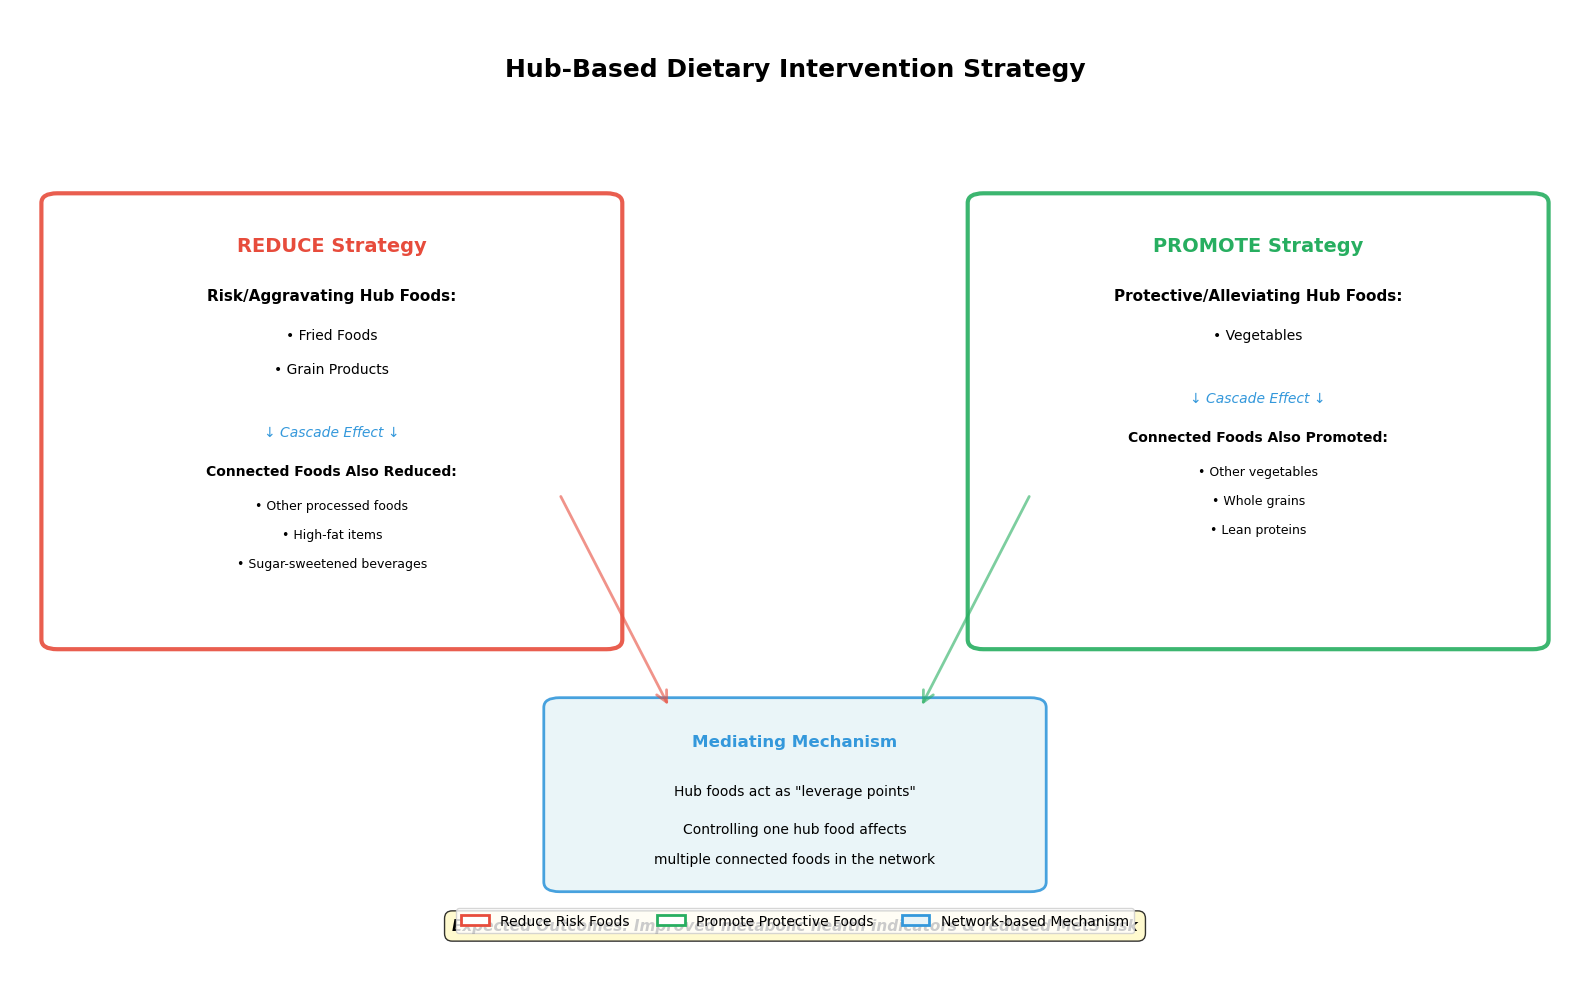

In [21]:
# FIGURE 2: Integrated Dietary Strategy Framework
# Conceptual diagram showing hub-based intervention strategies

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Load classification results
try:
    df_prev_summary = pd.read_csv(TABLES_DIR / 'Table_4_Summary_Prevention_Classification.csv')
    df_mgmt_summary = pd.read_csv(TABLES_DIR / 'Table_5_Summary_Management_Classification.csv')
except:
    print("Warning: Classification tables not found. Please run Table 4 and 5 cells first.")
    df_prev_summary = pd.DataFrame()
    df_mgmt_summary = pd.DataFrame()

# Aggregate risk and protective hubs across all groups
risk_hubs = set()
protective_hubs = set()

if not df_prev_summary.empty:
    risk_prev = df_prev_summary[df_prev_summary['Classification'] == 'Risk Factor']['Hub_Food'].unique()
    protective_prev = df_prev_summary[df_prev_summary['Classification'] == 'Protective Factor']['Hub_Food'].unique()
    risk_hubs.update(risk_prev)
    protective_hubs.update(protective_prev)

if not df_mgmt_summary.empty:
    aggravating = df_mgmt_summary[df_mgmt_summary['Classification'] == 'Aggravating Factor']['Hub_Food'].unique()
    alleviating = df_mgmt_summary[df_mgmt_summary['Classification'] == 'Alleviating Factor']['Hub_Food'].unique()
    risk_hubs.update(aggravating)
    protective_hubs.update(alleviating)

# Remove overlaps (if a food appears in both, categorize based on frequency)
overlaps = risk_hubs & protective_hubs
risk_hubs = risk_hubs - overlaps
protective_hubs = protective_hubs - overlaps

print(f"Risk/Aggravating Hubs: {risk_hubs}")
print(f"Protective/Alleviating Hubs: {protective_hubs}")

# Create conceptual diagram
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Hub-Based Dietary Intervention Strategy', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Color scheme
RISK_COLOR = '#E74C3C'
PROTECTIVE_COLOR = '#27AE60'
MEDIATING_COLOR = '#3498DB'

# Left panel: REDUCE strategy
reduce_box = FancyBboxPatch((0.3, 3.5), 3.5, 4.5, 
                            boxstyle="round,pad=0.1", 
                            edgecolor=RISK_COLOR, facecolor='white', 
                            linewidth=3, alpha=0.9)
ax.add_patch(reduce_box)

ax.text(2.05, 7.5, 'REDUCE Strategy', ha='center', fontsize=14, 
        fontweight='bold', color=RISK_COLOR)

y_pos = 7.0
ax.text(2.05, y_pos, 'Risk/Aggravating Hub Foods:', ha='center', 
        fontsize=11, fontweight='bold')
y_pos -= 0.4

if risk_hubs:
    for hub in sorted(risk_hubs)[:5]:  # Show top 5
        ax.text(2.05, y_pos, f'• {hub}', ha='center', fontsize=10)
        y_pos -= 0.35
else:
    ax.text(2.05, y_pos, '(Run analysis to identify)', ha='center', 
            fontsize=10, style='italic', color='gray')
    y_pos -= 0.35

y_pos -= 0.3
ax.text(2.05, y_pos, '↓ Cascade Effect ↓', ha='center', fontsize=10, 
        style='italic', color=MEDIATING_COLOR)
y_pos -= 0.4

ax.text(2.05, y_pos, 'Connected Foods Also Reduced:', ha='center', 
        fontsize=10, fontweight='bold')
y_pos -= 0.35
ax.text(2.05, y_pos, '• Other processed foods', ha='center', fontsize=9)
y_pos -= 0.3
ax.text(2.05, y_pos, '• High-fat items', ha='center', fontsize=9)
y_pos -= 0.3
ax.text(2.05, y_pos, '• Sugar-sweetened beverages', ha='center', fontsize=9)

# Right panel: PROMOTE strategy
promote_box = FancyBboxPatch((6.2, 3.5), 3.5, 4.5, 
                             boxstyle="round,pad=0.1", 
                             edgecolor=PROTECTIVE_COLOR, facecolor='white', 
                             linewidth=3, alpha=0.9)
ax.add_patch(promote_box)

ax.text(7.95, 7.5, 'PROMOTE Strategy', ha='center', fontsize=14, 
        fontweight='bold', color=PROTECTIVE_COLOR)

y_pos = 7.0
ax.text(7.95, y_pos, 'Protective/Alleviating Hub Foods:', ha='center', 
        fontsize=11, fontweight='bold')
y_pos -= 0.4

if protective_hubs:
    for hub in sorted(protective_hubs)[:5]:  # Show top 5
        ax.text(7.95, y_pos, f'• {hub}', ha='center', fontsize=10)
        y_pos -= 0.35
else:
    ax.text(7.95, y_pos, '(Run analysis to identify)', ha='center', 
            fontsize=10, style='italic', color='gray')
    y_pos -= 0.35

y_pos -= 0.3
ax.text(7.95, y_pos, '↓ Cascade Effect ↓', ha='center', fontsize=10, 
        style='italic', color=MEDIATING_COLOR)
y_pos -= 0.4

ax.text(7.95, y_pos, 'Connected Foods Also Promoted:', ha='center', 
        fontsize=10, fontweight='bold')
y_pos -= 0.35
ax.text(7.95, y_pos, '• Other vegetables', ha='center', fontsize=9)
y_pos -= 0.3
ax.text(7.95, y_pos, '• Whole grains', ha='center', fontsize=9)
y_pos -= 0.3
ax.text(7.95, y_pos, '• Lean proteins', ha='center', fontsize=9)

# Center: Mediating mechanism
center_box = FancyBboxPatch((3.5, 1.0), 3.0, 1.8, 
                            boxstyle="round,pad=0.1", 
                            edgecolor=MEDIATING_COLOR, facecolor='#E8F4F8', 
                            linewidth=2, alpha=0.9)
ax.add_patch(center_box)

ax.text(5.0, 2.4, 'Mediating Mechanism', ha='center', fontsize=12, 
        fontweight='bold', color=MEDIATING_COLOR)
ax.text(5.0, 1.9, 'Hub foods act as "leverage points"', ha='center', fontsize=10)
ax.text(5.0, 1.5, 'Controlling one hub food affects', ha='center', fontsize=10)
ax.text(5.0, 1.2, 'multiple connected foods in the network', ha='center', fontsize=10)

# Arrows from strategies to mechanism
arrow1 = FancyArrowPatch((3.5, 5.0), (4.2, 2.8),
                        arrowstyle='->', mutation_scale=20, 
                        linewidth=2, color=RISK_COLOR, alpha=0.6)
ax.add_patch(arrow1)

arrow2 = FancyArrowPatch((6.5, 5.0), (5.8, 2.8),
                        arrowstyle='->', mutation_scale=20, 
                        linewidth=2, color=PROTECTIVE_COLOR, alpha=0.6)
ax.add_patch(arrow2)

# Bottom: Expected outcomes
ax.text(5.0, 0.5, 'Expected Outcomes: Improved metabolic health indicators & reduced MetS risk', 
        ha='center', fontsize=11, fontweight='bold', style='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4', alpha=0.8))

# Legend
legend_elements = [
    mpatches.Patch(facecolor='white', edgecolor=RISK_COLOR, linewidth=2, label='Reduce Risk Foods'),
    mpatches.Patch(facecolor='white', edgecolor=PROTECTIVE_COLOR, linewidth=2, label='Promote Protective Foods'),
    mpatches.Patch(facecolor='#E8F4F8', edgecolor=MEDIATING_COLOR, linewidth=2, label='Network-based Mechanism')
]
ax.legend(handles=legend_elements, loc='upper center', ncol=3, 
         frameon=True, fontsize=10, bbox_to_anchor=(0.5, 0.08))

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_2_Integrated_Dietary_Strategy.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved to: {output_file}")
plt.show()

## TABLE S3: Personalized_Coaching_Strategies

In [17]:
network_summary = pd.read_csv(OUTPUT_DIR / 'networks/ggm_network_summary.csv')

def get_top3_hubs(group_row):
    hubs = [
        group_row['Hub_1_Name'],
        group_row['Hub_2_Name'],
        group_row['Hub_3_Name']
    ]
    return [h for h in hubs if pd.notna(h)]

def classify_hubs(mets_plus_hubs, mets_minus_hubs):
    mets_plus_set = set(mets_plus_hubs)
    mets_minus_set = set(mets_minus_hubs)
    
    shared = list(mets_plus_set & mets_minus_set)
    risk = list(mets_plus_set - mets_minus_set)
    protective = list(mets_minus_set - mets_plus_set)
    
    return shared, risk, protective

def format_hub_list(hubs):
    if not hubs:
        return 'None'
    return ', '.join(hubs)

def calculate_network_diff(plus_row, minus_row):
    edge_diff = int(plus_row['N_Edges']) - int(minus_row['N_Edges'])
    mod_diff = plus_row['Modularity'] - minus_row['Modularity']
    
    edge_sign = '+' if edge_diff > 0 else ''
    mod_sign = '+' if mod_diff > 0 else ''
    
    return f"Δ Edges={edge_sign}{edge_diff}, Δ Modularity={mod_sign}{mod_diff:.3f}"

def generate_coaching_strategy(risk_hubs, protective_hubs):
    parts = []
    if risk_hubs:
        parts.append(f"Reduce: {', '.join(risk_hubs)}")
    if protective_hubs:
        parts.append(f"Promote: {', '.join(protective_hubs)}")
    
    return " | ".join(parts)

groups_info = [
    ('남성', '청년층(19-39세)', 'Male', 'Young (19-39y)'),
    ('남성', '중년층(40-59세)', 'Male', 'Middle-aged (40-59y)'),
    ('남성', '장년층(60-74세)', 'Male', 'Older (60-74y)'),
    ('여성', '청년층(19-39세)', 'Female', 'Young (19-39y)'),
    ('여성', '중년층(40-59세)', 'Female', 'Middle-aged (40-59y)'),
    ('여성', '장년층(60-74세)', 'Female', 'Older (60-74y)'),
]

table_s3_data = []

for sex_kr, age_kr, sex_en, age_en in groups_info:
    group_plus = f"{sex_kr}_{age_kr}_MetS(+)"
    group_minus = f"{sex_kr}_{age_kr}_MetS(-)"
    
    plus_rows = network_summary[network_summary['Group'] == group_plus]
    minus_rows = network_summary[network_summary['Group'] == group_minus]
    
    if plus_rows.empty or minus_rows.empty:
        continue
    
    plus_row = plus_rows.iloc[0]
    minus_row = minus_rows.iloc[0]
    
    mets_plus_hubs = get_top3_hubs(plus_row)
    mets_minus_hubs = get_top3_hubs(minus_row)
    
    shared_hubs, risk_hubs, protective_hubs = classify_hubs(mets_plus_hubs, mets_minus_hubs)
    
    network_diff = calculate_network_diff(plus_row, minus_row)
    coaching_strategy = generate_coaching_strategy(risk_hubs, protective_hubs)
    
    table_s3_data.append({
        'Sex': sex_en,
        'Age_Group': age_en,
        'N_MetS_Plus': int(plus_row['N_Samples']),
        'N_MetS_Minus': int(minus_row['N_Samples']),
        'MetS_Plus_Hubs': format_hub_list(mets_plus_hubs),
        'MetS_Minus_Hubs': format_hub_list(mets_minus_hubs),
        'Shared_Hubs': format_hub_list(shared_hubs),
        'Risk_Hubs_in_MetS': format_hub_list(risk_hubs),
        'Protective_Hubs_in_Healthy': format_hub_list(protective_hubs),
        'Network_Difference': network_diff,
        'Personalized_Coaching_Strategy': coaching_strategy
    })

table_s3 = pd.DataFrame(table_s3_data)
table_s3.to_csv(TABLES_DIR / 'Table_S3_Personalized_Coaching_Strategies.csv', index=False)
table_s3

,Sex,Age_Group,N_MetS_Plus,N_MetS_Minus,MetS_Plus_Hubs,MetS_Minus_Hubs,Shared_Hubs,Risk_Hubs_in_MetS,Protective_Hubs_in_Healthy,Network_Difference,Personalized_Coaching_Strategy
0,Male,Young (19-39y),516,1963,"Grain Products, Protein Foods, Fried Foods","Processed Foods, Protein Foods, Vegetables",Protein Foods,"Grain Products, Fried Foods","Vegetables, Processed Foods","Δ Edges=+3, Δ Modularity=-0.079","Reduce: Grain Products, Fried Foods | Promote:..."
1,Male,Middle-aged (40-59y),2938,4737,"Fried Foods, Processed Foods, Protein Foods","Fried Foods, Processed Foods, Vegetables","Processed Foods, Fried Foods",Protein Foods,Vegetables,"Δ Edges=0, Δ Modularity=-0.040",Reduce: Protein Foods | Promote: Vegetables
2,Male,Older (60-74y),971,1169,"Processed Foods, Protein Foods, Fruits","High Fat Meat, Processed Foods, Protein Foods","Processed Foods, Protein Foods",Fruits,High Fat Meat,"Δ Edges=+1, Δ Modularity=-0.031",Reduce: Fruits | Promote: High Fat Meat
3,Female,Middle-aged (40-59y),758,5629,"Fried Foods, High Fat Meat, Processed Foods","Processed Foods, Sugar-Sweetened Beverages, Fr...","Processed Foods, Fried Foods",High Fat Meat,Sugar-Sweetened Beverages,"Δ Edges=-3, Δ Modularity=+0.046",Reduce: High Fat Meat | Promote: Sugar-Sweeten...
4,Female,Older (60-74y),680,1084,"Protein Foods, Processed Foods, Sugar-Sweetene...","Fried Foods, Sugar-Sweetened Beverages, High F...",Sugar-Sweetened Beverages,"Processed Foods, Protein Foods","High Fat Meat, Fried Foods","Δ Edges=-2, Δ Modularity=+0.070","Reduce: Processed Foods, Protein Foods | Promo..."


# ETC

## FIGURE

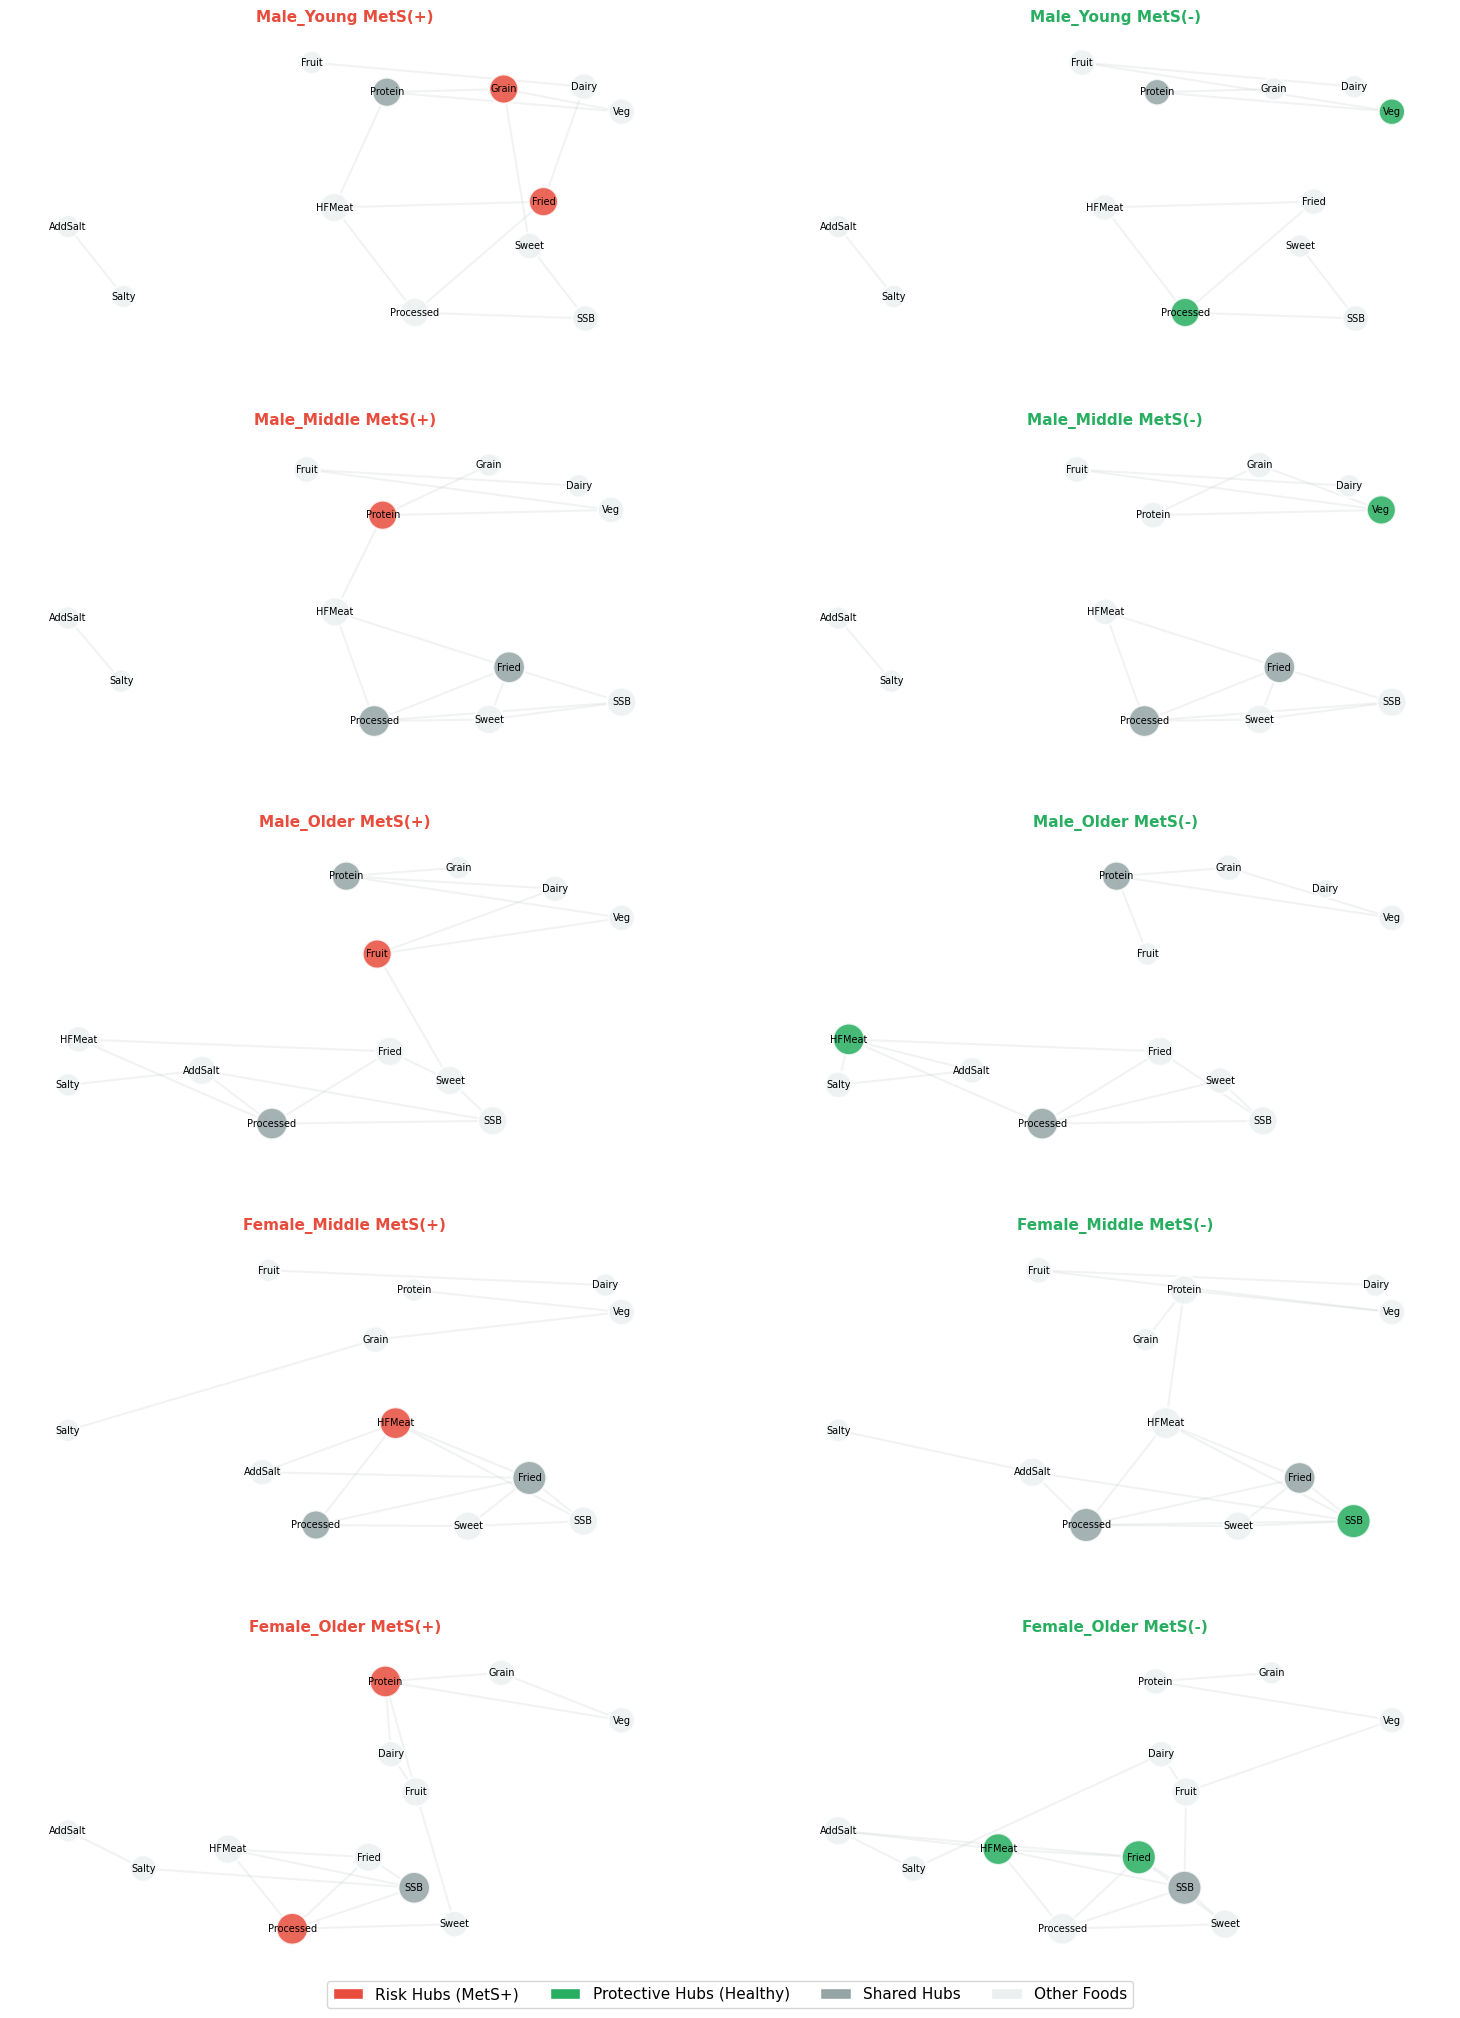

In [18]:
# Color scheme
RISK_COLOR = '#E74C3C'          # Red for Risk Hubs (REDUCE)
PROTECTIVE_COLOR = '#27AE60'    # Green for Protective Hubs (PROMOTE)
SHARED_COLOR = '#95A5A6'        # Gray for Shared Hubs
OTHER_COLOR = '#ECF0F1'         # Light gray for other foods
EDGE_COLOR = '#BDC3C7'          # Gray for edges

# Food abbreviations
FOOD_ABBREV = {
    'Grain Products': 'Grain',
    'Protein Foods': 'Protein',
    'Vegetables': 'Veg',
    'Dairy Products': 'Dairy',
    'Fruits': 'Fruit',
    'Fried Foods': 'Fried',
    'High Fat Meat': 'HFMeat',
    'Processed Foods': 'Processed',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'AddSalt',
    'Salty Food Consumption': 'Salty',
    'Sweet Food Consumption': 'Sweet'
}

def parse_hub_list(hub_string):
    if pd.isna(hub_string) or hub_string == 'None' or hub_string == 'N/A':
        return []
    return [h.strip() for h in str(hub_string).split(',')]

def get_node_color(node, risk_hubs, protective_hubs, shared_hubs):
    if node in risk_hubs:
        return RISK_COLOR
    elif node in protective_hubs:
        return PROTECTIVE_COLOR
    elif node in shared_hubs:
        return SHARED_COLOR
    else:
        return OTHER_COLOR

def draw_network_subplot(ax, G, pos, risk_hubs, protective_hubs, shared_hubs, hub_degrees, title, metrics_color):
    node_colors = [get_node_color(node, risk_hubs, protective_hubs, shared_hubs) for node in G.nodes()]
    hub_nodes = set(risk_hubs + protective_hubs + shared_hubs)
    node_sizes = []
    for node in G.nodes():
        degree = G.degree(node)
        node_sizes.append(degree * 80 + 200)
    
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=1.5, edge_color=EDGE_COLOR)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, 
                           alpha=0.85, edgecolors='white', linewidths=1.5)
    
    labels = {node: FOOD_ABBREV.get(node, node[:8]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7, font_weight='normal')
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color=metrics_color)
    ax.axis('off')

# Load data
table_s3 = pd.read_csv(TABLES_DIR / 'Table_S3_Personalized_Coaching_Strategies.csv')
network_summary = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
groups_to_plot = [
    ('남성', '청년층(19-39세)', 'Male', 'Young (19-39y)', 'Male_Young'),
    ('남성', '중년층(40-59세)', 'Male', 'Middle-aged (40-59y)', 'Male_Middle'),
    ('남성', '장년층(60-74세)', 'Male', 'Older (60-74y)', 'Male_Older'),
    ('여성', '중년층(40-59세)', 'Female', 'Middle-aged (40-59y)', 'Female_Middle'),
    ('여성', '장년층(60-74세)', 'Female', 'Older (60-74y)', 'Female_Older'),
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
plt.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.02, hspace=0.3, wspace=0.15)

for row, (sex_kr, age_kr, sex_en, age_en, label) in enumerate(groups_to_plot):
    s3_row = table_s3[(table_s3['Sex'] == sex_en) & (table_s3['Age_Group'] == age_en)].iloc[0]
    
    risk_hubs = parse_hub_list(s3_row['Risk_Hubs_in_MetS'])
    protective_hubs = parse_hub_list(s3_row['Protective_Hubs_in_Healthy'])
    shared_hubs = parse_hub_list(s3_row['Shared_Hubs'])
    
    G_plus = load_network(sex_kr, age_kr, 'MetS(+)')
    G_minus = load_network(sex_kr, age_kr, 'MetS(-)')
    
    # Get network statistics
    group_plus = f"{sex_kr}_{age_kr}_MetS(+)"
    group_minus = f"{sex_kr}_{age_kr}_MetS(-)"
    
    plus_row = network_summary[network_summary['Group'] == group_plus].iloc[0]
    minus_row = network_summary[network_summary['Group'] == group_minus].iloc[0]
    
    # Hub degrees (for node sizing)
    hub_degrees_plus = {
        plus_row['Hub_1_Name']: plus_row['Hub_1_Degree'],
        plus_row['Hub_2_Name']: plus_row['Hub_2_Degree'],
        plus_row['Hub_3_Name']: plus_row['Hub_3_Degree'],
    }
    
    hub_degrees_minus = {
        minus_row['Hub_1_Name']: minus_row['Hub_1_Degree'],
        minus_row['Hub_2_Name']: minus_row['Hub_2_Degree'],
        minus_row['Hub_3_Name']: minus_row['Hub_3_Degree'],
    }
    
    # Create consistent layout using combined graph
    all_nodes = list(set(list(G_plus.nodes()) + list(G_minus.nodes())))
    G_combined = nx.Graph()
    G_combined.add_nodes_from(all_nodes)
    G_combined.add_edges_from(G_plus.edges())
    G_combined.add_edges_from(G_minus.edges())
    pos = nx.spring_layout(G_combined, seed=42, k=2.5, iterations=100)
    
    # Draw MetS(+) network (left column)
    draw_network_subplot(
        axes[row, 0], G_plus, pos, risk_hubs, [], shared_hubs, 
        hub_degrees_plus, f'{label} MetS(+)', RISK_COLOR
    )
    
    # Draw MetS(-) network (right column)
    draw_network_subplot(
        axes[row, 1], G_minus, pos, [], protective_hubs, shared_hubs, 
        hub_degrees_minus, f'{label} MetS(-)', PROTECTIVE_COLOR
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RISK_COLOR, edgecolor='white', label='Risk Hubs (MetS+)'),
    Patch(facecolor=PROTECTIVE_COLOR, edgecolor='white', label='Protective Hubs (Healthy)'),
    Patch(facecolor=SHARED_COLOR, edgecolor='white', label='Shared Hubs'),
    Patch(facecolor=OTHER_COLOR, edgecolor='white', label='Other Foods')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
            frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.01))

# Save figure
output_path = FIGURES_DIR / 'Figure_3_Individual_Networks_Grid.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

## FIGURE: Metabolic Syndrome Effects on Dietary Network Structure

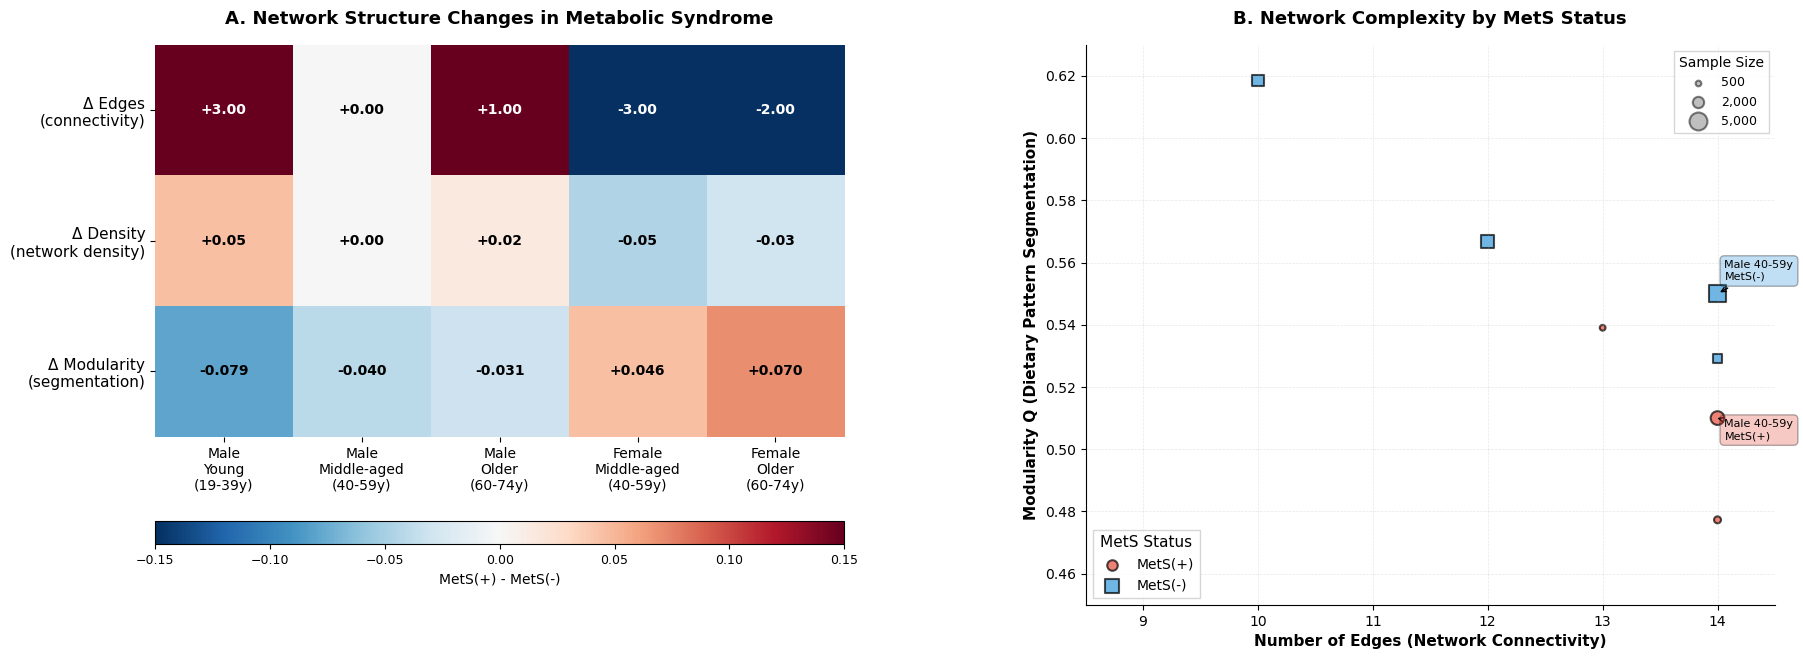

In [19]:
def prepare_mets_differences(network_df):
    groups = [
        ('Male', 'Young\n(19-39y)', '남성_청년층(19-39세)'),
        ('Male', 'Middle-aged\n(40-59y)', '남성_중년층(40-59세)'),
        ('Male', 'Older\n(60-74y)', '남성_장년층(60-74세)'),
        ('Female', 'Young\n(19-39y)', '여성_청년층(19-39세)'),
        ('Female', 'Middle-aged\n(40-59y)', '여성_중년층(40-59세)'),
        ('Female', 'Older\n(60-74y)', '여성_장년층(60-74세)'),
    ]
    
    results = []
    for sex, age_label, group_prefix in groups:
        mets_plus = network_df[network_df['Group'] == f"{group_prefix}_MetS(+)"]
        mets_minus = network_df[network_df['Group'] == f"{group_prefix}_MetS(-)"]
        
        if len(mets_plus) == 0 or len(mets_minus) == 0:
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': np.nan,
                'Delta_Density': np.nan,
                'Delta_Modularity': np.nan,
                'Delta_Communities': np.nan,
                'N_Plus': 0,
                'N_Minus': mets_minus.iloc[0]['N_Samples'] if len(mets_minus) > 0 else 0
            })
        else:
            plus = mets_plus.iloc[0]
            minus = mets_minus.iloc[0]
            
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': plus['N_Edges'] - minus['N_Edges'],
                'Delta_Density': plus['Density'] - minus['Density'],
                'Delta_Modularity': plus['Modularity'] - minus['Modularity'],
                'Delta_Communities': plus['N_Communities'] - minus['N_Communities'],
                'N_Plus': plus['N_Samples'],
                'N_Minus': minus['N_Samples']
            })
    
    return pd.DataFrame(results)

def plot_panel_a_metrics_heatmap(ax, diff_df):
    diff_df_valid = diff_df.dropna(subset=['Delta_Edges'])
    diff_df_valid['Group'] = diff_df_valid['Sex'] + '\n' + diff_df_valid['Age']
    
    metrics = ['Delta_Edges', 'Delta_Density', 'Delta_Modularity']
    metric_labels = ['Δ Edges\n(connectivity)', 'Δ Density\n(network density)', 'Δ Modularity\n(segmentation)']
    
    # Create matrix
    matrix = diff_df_valid[metrics].values
    im = ax.imshow(matrix.T, cmap='RdBu_r', aspect='auto', vmin=-0.15, vmax=0.15)
    
    # Set ticks
    ax.set_xticks(range(len(diff_df_valid)))
    ax.set_xticklabels(diff_df_valid['Group'], rotation=0, ha='center', fontsize=10)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metric_labels, fontsize=11)
    
    # Add values as text
    for i in range(len(metrics)):
        for j in range(len(diff_df_valid)):
            value = matrix[j, i]
            if not np.isnan(value):
                text_color = 'white' if abs(value) > 0.08 else 'black'
                text = f'{value:+.2f}' if i < 2 else f'{value:+.3f}'
                ax.text(j, i, text,
                       ha='center', va='center', color=text_color, 
                       fontsize=10, weight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, aspect=30)
    cbar.set_label('MetS(+) - MetS(-)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    
    ax.set_title('A. Network Structure Changes in Metabolic Syndrome', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def plot_panel_b_network_complexity(ax, network_df):
    mets_plus = network_df[network_df['MetS_Status'] == 'MetS(+)']
    mets_minus = network_df[network_df['MetS_Status'] == 'MetS(-)']
    
    # Plot scatter
    scatter1 = ax.scatter(mets_plus['N_Edges'], mets_plus['Modularity'], 
                         s=mets_plus['N_Samples']/30, c='#E74C3C', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(+)', marker='o')
    scatter2 = ax.scatter(mets_minus['N_Edges'], mets_minus['Modularity'], 
                         s=mets_minus['N_Samples']/30, c='#3498DB', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(-)', marker='s')
    
    male_middle_plus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(+)'].iloc[0]
    male_middle_minus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(-)'].iloc[0]
    
    ax.annotate('Male 40-59y\nMetS(+)', 
                xy=(male_middle_plus['N_Edges'], male_middle_plus['Modularity']),
                xytext=(5, -15), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#E74C3C', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    ax.annotate('Male 40-59y\nMetS(-)', 
                xy=(male_middle_minus['N_Edges'], male_middle_minus['Modularity']),
                xytext=(5, 10), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#3498DB', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    # Axes labels
    ax.set_xlabel('Number of Edges (Network Connectivity)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Modularity Q (Dietary Pattern Segmentation)', fontsize=11, fontweight='bold')
    ax.set_xlim(8.5, 14.5)
    ax.set_ylim(0.45, 0.63)
    
    # Add legend for MetS status
    legend1 = ax.legend(loc='lower left', frameon=True, fancybox=False, 
                       fontsize=10, title='MetS Status', title_fontsize=11)
    
    # Add size legend
    sizes = [500, 2000, 5000]
    size_labels = ['500', '2,000', '5,000']
    legend_elements = [plt.scatter([], [], s=s/30, c='gray', alpha=0.5, 
                                  edgecolors='black', linewidths=1.5) 
                      for s in sizes]
    legend2 = ax.legend(legend_elements, size_labels, title='Sample Size', 
                       loc='upper right', frameon=True, fancybox=False, 
                       fontsize=9, title_fontsize=10)
    ax.add_artist(legend1)
    
    ax.set_title('B. Network Complexity by MetS Status', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

network_df = pd.read_csv('../result/networks/ggm_network_summary.csv')
diff_df = prepare_mets_differences(network_df)

fig = plt.figure(figsize=(18, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.30, wspace=0.35, left=0.06, right=0.96, top=0.90, bottom=0.10)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

plot_panel_a_metrics_heatmap(ax_a, diff_df)
plot_panel_b_network_complexity(ax_b, network_df)

output_file = FIGURES_DIR / 'Supplementary_Figure_3_MetS_Network_Effects.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')